<a href="https://colab.research.google.com/github/ys5591/Yunsu-Shin/blob/main/01_glmhmm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### 1. Paths

Open `01_glmhmm.ipynb` in a fresh Colab runtime and run all cells. At the
upload prompt, select `01_model_comparison_inputs.zip`. Alternatively upload
the two researcher-corrected CSV files supplied with this revision.

The behavioral input is the exact uploaded `working_memory_glmhmm_input_data(3).csv`,
saved under `working_memory_glmhmm_input_data.csv`. The recorded cumulative
reference comes from the uploaded `trials_clean(2).csv`, including its nine
user-supplied count corrections. Its Sd82 final-trial key is aligned from 31 to
29 to match the corrected behavioral input. Counts are not recalculated during
loading. The archive retains the original counts and the 11 specific user edits
(nine counts, one trial number, and one delay) in `correction_history.csv`.
These are researcher-supplied corrections, not independent experimental verification.

All 12,150 trials, 405 sessions and 45 mice are retained. Source labels and
reviewed cumulative counts must pass strict assertions in all three analysis
sections; discrepancies still stop fitting.

The four requested changes are retained: select EM restarts by recomputed
`final_train_ll`; validate source task-rule labels and cumulative counts;
include previous choice × previous reward via `prev_correct_side_signed` in
the HMM and K=1 emissions GLMs; propagate likelihood and initialization errors
without dropping transition inputs.

The analysis structure, output names and fitting settings are retained.
Outputs are written under `outputs_01/`. Run the notebook to refit the models:
previous state solutions and numerical results cannot be reused after the
regressor and initialization-selection changes.


In [1]:
from pathlib import Path
import csv, hashlib, io, json, zipfile

BASE=Path.cwd()
INPUT_DIR=BASE/"inputs_01"
OUTPUT_ROOT=BASE/"outputs_01"
INPUT_DIR.mkdir(parents=True,exist_ok=True)
OUTPUT_ROOT.mkdir(parents=True,exist_ok=True)
INPUT_SHA256={'recorded_cumulative_reference.csv': 'bc180057eb9ef20a64bdf6e29ee4df60b72049bbaec082129e64d9631e55fa38', 'working_memory_glmhmm_input_data.csv': '08162c5a7bc351b148809a576a4ab3363335659d8d7a6a97a9c0885a52350da0'}
SOURCE_FILENAME="working_memory_glmhmm_input_data.csv"
SOURCE_CSV_PATH=INPUT_DIR/"working_memory_glmhmm_input_data.csv"
SOURCE_SHA256=INPUT_SHA256[SOURCE_CSV_PATH.name]
RECORDED_CUMULATIVE_PATH=INPUT_DIR/"recorded_cumulative_reference.csv"
REVIEWED_CLEAN_SHA256="5882340f61a85a8deddb112711b4dd4cf9b198ef5d6c4dcdcf3702a404368663"

def register_input_bytes(data):
    digest=hashlib.sha256(data).hexdigest()
    for name,expected in INPUT_SHA256.items():
        if digest==expected:
            (INPUT_DIR/name).write_bytes(data)
            return True
    if digest==REVIEWED_CLEAN_SHA256:
        reader=csv.DictReader(io.StringIO(data.decode("utf-8-sig")))
        fields=["session_id","trial_in_session","correct_cumulative_original"]
        buffer=io.StringIO()
        writer=csv.DictWriter(buffer,fieldnames=fields,lineterminator="\n")
        writer.writeheader()
        for row in reader:
            # Align the reviewed reference key to the user's corrected final trial number.
            # User-corrected cumulative values are preserved without recalculation.
            if row["session_id"] == "Sd82_Testing1-60_195" and row["trial_in_session"] == "31":
                row["trial_in_session"] = "29"
            writer.writerow({col:row[col] for col in fields})
        recorded=buffer.getvalue().encode("utf-8")
        assert hashlib.sha256(recorded).hexdigest()==INPUT_SHA256[RECORDED_CUMULATIVE_PATH.name]
        RECORDED_CUMULATIVE_PATH.write_bytes(recorded)
        return True
    return False

def register_upload(data):
    if register_input_bytes(data):return
    if zipfile.is_zipfile(io.BytesIO(data)):
        with zipfile.ZipFile(io.BytesIO(data)) as archive:
            for member in archive.infolist():
                if member.filename.lower().endswith(".csv"):
                    register_input_bytes(archive.read(member))

def missing_inputs():
    return [name for name,expected in INPUT_SHA256.items()
            if not (INPUT_DIR/name).is_file()
            or hashlib.sha256((INPUT_DIR/name).read_bytes()).hexdigest()!=expected]

for path in BASE.glob("*.csv"):
    register_input_bytes(path.read_bytes())
bundle=BASE/"01_model_comparison_inputs.zip"
if bundle.is_file():register_upload(bundle.read_bytes())
if missing_inputs():
    try:
        from google.colab import files
    except ImportError:
        files=None
    if files is not None:
        print("Upload 01_model_comparison_inputs.zip (corrected input plus reviewed cumulative reference).")
        for data in files.upload().values():register_upload(data)
if missing_inputs():
    raise FileNotFoundError("Missing reviewed input(s): "+", ".join(missing_inputs()))

source_bytes=SOURCE_CSV_PATH.read_bytes()
(INPUT_DIR/"trials_no_delay.csv").write_bytes(source_bytes)
reader=csv.DictReader(io.StringIO(source_bytes.decode("utf-8-sig")))
source_columns=list(reader.fieldnames or [])
source_rows=list(reader)
assert "delay_s_posthoc_only" in source_columns
with (INPUT_DIR/"trials_clean.csv").open("w",newline="",encoding="utf-8") as handle:
    writer=csv.DictWriter(handle,fieldnames=source_columns+["delay_s"])
    writer.writeheader()
    for row in source_rows:
        writer.writerow({**row,"delay_s":row["delay_s_posthoc_only"]})
(OUTPUT_ROOT/"input_provenance.json").write_text(json.dumps({
    "authoritative_behavior_source":SOURCE_FILENAME,"source_sha256":SOURCE_SHA256,
    "n_source_rows":len(source_rows),"recorded_cumulative_source":"user-corrected trials_clean(2).csv; 9 researcher-supplied count corrections; Sd82 reference key aligned 31 to 29",
    "recorded_reference_sha256":INPUT_SHA256[RECORDED_CUMULATIVE_PATH.name],
    "reviewed_clean_sha256":REVIEWED_CLEAN_SHA256,
    "correction_history":"correction_history.csv in the input archive; original counts preserved in audit/",
    "input_transform":"delay_s aliases source delay_s_posthoc_only; no source records changed or excluded",
    "task_rule_policy":"strict source-label and independent recorded cumulative assertions"},indent=2))
print(f"Input files registered: {len(source_rows):,} trials. Task-rule validation is required before fitting.")


Input files registered: 12,150 trials. Task-rule validation is required before fitting.


#### 2. Initial model

In [2]:
import sys, subprocess, importlib, importlib.util

packages = {
    "numpy": "numpy", "pandas": "pandas", "scipy": "scipy",
    "matplotlib": "matplotlib", "sklearn": "scikit-learn",
    "openpyxl": "openpyxl", "IPython": "ipython", "autograd": "autograd",
    "numba": "numba", "tqdm": "tqdm", "Cython": "cython", "setuptools": "setuptools", "wheel": "wheel",
}
missing = [package for module, package in packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

try:
    import ssm
    if not hasattr(ssm, "HMM_TO"):
        raise ImportError("HMM_TO is missing from the installed ssm package.")
except ImportError:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--no-build-isolation", "--no-deps", "--force-reinstall",
        "git+https://github.com/Zeinab-Mohammadi/ssm.git@35377d405185b39be22ca459dbf5a66122e5d636",
    ])
    importlib.invalidate_caches()
    for module in list(sys.modules):
        if module == "ssm" or module.startswith("ssm."):
            del sys.modules[module]
    import ssm

assert hasattr(ssm, "HMM_TO"), "The installed ssm package must include HMM_TO."
IN_COLAB = "google.colab" in sys.modules


In [3]:
import os, re, json, math, copy, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

PROJECT_DIR = OUTPUT_ROOT / "01_initial"
DATA_DIR = PROJECT_DIR
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CLEAN_CSV_PATH = INPUT_DIR / "trials_clean.csv"
CSV_CANDIDATES = [CLEAN_CSV_PATH]
CSV_FILENAME = CLEAN_CSV_PATH.name
RANDOM_SEED = 0
N_FOLDS = 5
TAU = 4.0
K_LIST = [2, 3]
N_INITS = 3
N_EM_ITERS = 150
PRIOR_SIGMA = 100.0
TRANSITION_ALPHA = 1.0

#### Shared summaries

In [4]:
def decode_early_states(
    K_TO_INTERPRET,
    RESULTS_DIR,
    best_by_K_fold,
    df_model,
    fold_mapping_session,
    obs_mat,
    obs_regressor_names,
    output,
    session,
    trans_mat,
    trans_regressor_names,
):
    base_df = df_model.copy().reset_index(drop=True)
    base_df["global_trial_index"] = np.arange(len(base_df))
    decoded_df = base_df.copy()
    decoded_df["raw_decoded_state"] = np.nan
    decoded_df["decoded_state"] = np.nan
    decoded_df["max_state_prob"] = np.nan
    decoded_df["decoded_by_fold"] = np.nan
    for k in range(K_TO_INTERPRET):
        decoded_df[f"p_state_{k}"] = np.nan
    weight_rows = []
    transition_rows = []
    sub_models = best_by_K_fold[best_by_K_fold["K"] == K_TO_INTERPRET].copy()
    if len(sub_models) == 0:
        raise ValueError(f"No saved models found for K={K_TO_INTERPRET}.")
    session_array = np.asarray(session).astype(str)
    for _, row in sub_models.iterrows():
        fold = int(row["fold"])
        model_fold, payload_fold = reconstruct_model_from_row(row)
        test_sessions = fold_mapping_session[fold_mapping_session[:, 1].astype(int) == fold, 0].astype(str)
        test_idx = np.isin(session_array, test_sessions)
        inputs_obs, inputs_trans, datas, masks, session_ids = segment_by_session(
            obs_mat[test_idx], trans_mat[test_idx], output[test_idx], session_array[test_idx]
        )
        obs_w = get_observation_weight_matrix(model_fold)
        correct_idx = obs_regressor_names.index("correct_side_signed")
        order = np.argsort(-obs_w[:, correct_idx])
        raw_to_canonical = {int(raw): int(rank) for rank, raw in enumerate(order)}
        for canonical_state, raw_state in enumerate(order):
            for reg_i, reg_name in enumerate(obs_regressor_names):
                weight_rows.append(
                    {
                        "fold": fold,
                        "canonical_state": canonical_state,
                        "raw_state": int(raw_state),
                        "regressor": reg_name,
                        "weight": float(obs_w[raw_state, reg_i]),
                    }
                )
        trans_w = get_transition_weight_array(model_fold, K_TO_INTERPRET, len(trans_regressor_names))
        if trans_w is not None:
            trans_w = trans_w[np.ix_(order, order, np.arange(len(trans_regressor_names)))]
            for from_state in range(K_TO_INTERPRET):
                for to_state in range(K_TO_INTERPRET):
                    for reg_i, reg_name in enumerate(trans_regressor_names):
                        transition_rows.append(
                            {
                                "fold": fold,
                                "from_canonical_state": from_state,
                                "to_canonical_state": to_state,
                                "regressor": reg_name,
                                "weight": float(trans_w[from_state, to_state, reg_i]),
                            }
                        )
        for sid, xobs, xtr, yseq, mseq in zip(session_ids, inputs_obs, inputs_trans, datas, masks):
            gamma_raw = expected_state_probs_one_session(
                model=model_fold, data=yseq, obs_input=xobs, trans_input=xtr, mask=mseq
            )
            gamma = gamma_raw[:, order]
            canonical_state = gamma.argmax(axis=1)
            max_prob = gamma.max(axis=1)
            raw_state = gamma_raw.argmax(axis=1)
            idx_global = np.where(session_array == str(sid))[0]
            if len(idx_global) != len(canonical_state):
                raise ValueError(
                    f"Session length mismatch for {sid}: {len(idx_global)} rows vs {len(canonical_state)} decoded states."
                )
            decoded_df.loc[idx_global, "raw_decoded_state"] = raw_state
            decoded_df.loc[idx_global, "decoded_state"] = canonical_state
            decoded_df.loc[idx_global, "max_state_prob"] = max_prob
            decoded_df.loc[idx_global, "decoded_by_fold"] = fold
            for k in range(K_TO_INTERPRET):
                decoded_df.loc[idx_global, f"p_state_{k}"] = gamma[:, k]
    if decoded_df["decoded_state"].isna().any():
        missing_n = int(decoded_df["decoded_state"].isna().sum())
        raise ValueError(f"{missing_n} trials were not decoded.")
    decoded_df["decoded_state"] = decoded_df["decoded_state"].astype(int)
    decoded_df["raw_decoded_state"] = decoded_df["raw_decoded_state"].astype(int)
    decoded_df["decoded_by_fold"] = decoded_df["decoded_by_fold"].astype(int)
    decoded_path = RESULTS_DIR / f"crossvalidated_decoded_trials_K{K_TO_INTERPRET}.csv"
    decoded_df.to_csv(decoded_path, index=False)
    state_weight_long = pd.DataFrame(weight_rows)
    state_weight_long_path = RESULTS_DIR / f"cv_observation_weights_long_K{K_TO_INTERPRET}.csv"
    state_weight_long.to_csv(state_weight_long_path, index=False)
    state_weight_summary = (
        state_weight_long.groupby(["canonical_state", "regressor"])
        .agg(
            mean_weight=("weight", "mean"),
            std_weight=("weight", "std"),
            min_weight=("weight", "min"),
            max_weight=("weight", "max"),
        )
        .reset_index()
    )
    state_weight_summary_path = RESULTS_DIR / f"cv_observation_weights_summary_K{K_TO_INTERPRET}.csv"
    state_weight_summary.to_csv(state_weight_summary_path, index=False)
    if len(transition_rows) > 0:
        transition_weight_long = pd.DataFrame(transition_rows)
        transition_weight_long_path = RESULTS_DIR / f"cv_transition_weights_long_K{K_TO_INTERPRET}.csv"
        transition_weight_long.to_csv(transition_weight_long_path, index=False)
        transition_weight_summary = (
            transition_weight_long.groupby(["from_canonical_state", "to_canonical_state", "regressor"])
            .agg(mean_weight=("weight", "mean"), std_weight=("weight", "std"))
            .reset_index()
        )
        transition_weight_summary_path = RESULTS_DIR / f"cv_transition_weights_summary_K{K_TO_INTERPRET}.csv"
        transition_weight_summary.to_csv(transition_weight_summary_path, index=False)
    plt.figure(figsize=(7, 4))
    plt.hist(decoded_df["max_state_prob"], bins=30)
    plt.xlabel("Max posterior state probability")
    plt.ylabel("Number of trials")
    plt.title(f"Cross-validated posterior confidence, K={K_TO_INTERPRET}")
    plt.tight_layout()
    fig_path = RESULTS_DIR / f"cv_posterior_confidence_K{K_TO_INTERPRET}.png"
    plt.savefig(fig_path, dpi=300)
    plt.show()
    return (decoded_df, state_weight_summary)

In [5]:
def summarize_early_states(K_TO_INTERPRET, RESULTS_DIR, decoded_df, state_weight_summary):
    state_summary = (
        decoded_df.dropna(subset=["decoded_state"])
        .groupby("decoded_state")
        .agg(
            n_trials=("decoded_state", "size"),
            mean_accuracy=("trial_correct", "mean"),
            mean_right_choice_rate=("choice_right", "mean"),
            mean_max_state_prob=("max_state_prob", "mean"),
        )
        .reset_index()
    )
    state_summary["occupancy"] = state_summary["n_trials"] / len(decoded_df)
    if "repeat_choice" in decoded_df.columns:
        repeat_summary = (
            decoded_df.dropna(subset=["decoded_state"])
            .groupby("decoded_state")
            .agg(mean_repeat_choice_rate=("repeat_choice", "mean"))
            .reset_index()
        )
        state_summary = state_summary.merge(repeat_summary, on="decoded_state", how="left")
    if "prev_reward_signed" in decoded_df.columns:
        reward_summary = (
            decoded_df.dropna(subset=["decoded_state"])
            .groupby("decoded_state")
            .agg(mean_prev_reward=("prev_reward_signed", "mean"))
            .reset_index()
        )
        state_summary = state_summary.merge(reward_summary, on="decoded_state", how="left")
    weight_wide = (
        state_weight_summary.pivot(index="canonical_state", columns="regressor", values="mean_weight")
        .reset_index()
        .rename(columns={"canonical_state": "decoded_state"})
    )
    state_summary = state_summary.merge(weight_wide, on="decoded_state", how="left")
    state_summary["exploratory_state_label"] = state_summary.apply(label_state_from_weights, axis=1)
    state_label_table = state_summary[["decoded_state", "exploratory_state_label"]].copy()
    state_summary_path = RESULTS_DIR / f"state_summary_K{K_TO_INTERPRET}.csv"
    state_summary.to_csv(state_summary_path, index=False)
    occ_delay_counts = (
        decoded_df.dropna(subset=["delay_s", "decoded_state"])
        .groupby(["delay_s", "decoded_state"])
        .size()
        .reset_index(name="n_trials")
    )
    delay_totals = (
        decoded_df.dropna(subset=["delay_s", "decoded_state"])
        .groupby("delay_s")
        .size()
        .reset_index(name="n_delay_trials")
    )
    occupancy_by_delay = occ_delay_counts.merge(delay_totals, on="delay_s", how="left")
    occupancy_by_delay["fractional_occupancy"] = (
        occupancy_by_delay["n_trials"] / occupancy_by_delay["n_delay_trials"]
    )
    occupancy_by_delay_path = RESULTS_DIR / f"state_occupancy_by_delay_K{K_TO_INTERPRET}.csv"
    occupancy_by_delay.to_csv(occupancy_by_delay_path, index=False)
    occ_mouse_delay_counts = (
        decoded_df.dropna(subset=["mouse_id", "delay_s", "decoded_state"])
        .groupby(["mouse_id", "delay_s", "decoded_state"])
        .size()
        .reset_index(name="n_trials")
    )
    mouse_delay_totals = (
        decoded_df.dropna(subset=["mouse_id", "delay_s", "decoded_state"])
        .groupby(["mouse_id", "delay_s"])
        .size()
        .reset_index(name="n_mouse_delay_trials")
    )
    occupancy_by_mouse_delay = occ_mouse_delay_counts.merge(
        mouse_delay_totals, on=["mouse_id", "delay_s"], how="left"
    )
    occupancy_by_mouse_delay["fractional_occupancy"] = (
        occupancy_by_mouse_delay["n_trials"] / occupancy_by_mouse_delay["n_mouse_delay_trials"]
    )
    occupancy_by_mouse_delay_path = RESULTS_DIR / f"state_occupancy_by_mouse_delay_K{K_TO_INTERPRET}.csv"
    occupancy_by_mouse_delay.to_csv(occupancy_by_mouse_delay_path, index=False)
    plt.figure(figsize=(7, 5))
    for st in sorted(occupancy_by_delay["decoded_state"].unique()):
        sub = occupancy_by_delay[occupancy_by_delay["decoded_state"] == st]
        plt.plot(sub["delay_s"], sub["fractional_occupancy"], marker="o", label=f"State {int(st)}")
    plt.xlabel("Delay (s)")
    plt.ylabel("Fractional occupancy")
    plt.title(f"State occupancy by delay, K={K_TO_INTERPRET}")
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    fig_path = RESULTS_DIR / f"state_occupancy_by_delay_K{K_TO_INTERPRET}.png"
    plt.savefig(fig_path, dpi=300)
    plt.show()
    return state_summary

In [6]:
def summarize_early_switches(K_TO_INTERPRET, RESULTS_DIR, decoded_df):
    switch_rows = []
    dwell_rows = []
    for sid, sub in decoded_df.sort_values(["session_id", "trial_in_session"]).groupby(
        "session_id", sort=False
    ):
        sub = sub.dropna(subset=["decoded_state"]).copy()
        if len(sub) == 0:
            continue
        states = sub["decoded_state"].astype(int).to_numpy()
        n_switches = int(np.sum(states[1:] != states[:-1])) if len(states) > 1 else 0
        switch_rows.append(
            {
                "session_id": sid,
                "mouse_id": sub["mouse_id"].iloc[0] if "mouse_id" in sub.columns else np.nan,
                "delay_s": (sub["delay_s"].iloc[0]
                            if "delay_s" in sub.columns and sub["delay_s"].nunique() == 1 else np.nan),
                "mixed_delay_session": (sub["delay_s"].nunique() > 1 if "delay_s" in sub.columns else False),
                "n_trials": len(sub),
                "n_state_switches": n_switches,
                "switches_per_trial": n_switches / max(len(sub) - 1, 1),
            }
        )
        for st, dur in dwell_lengths(states):
            dwell_rows.append(
                {
                    "session_id": sid,
                    "mouse_id": sub["mouse_id"].iloc[0] if "mouse_id" in sub.columns else np.nan,
                    "delay_s": (sub["delay_s"].iloc[0]
                            if "delay_s" in sub.columns and sub["delay_s"].nunique() == 1 else np.nan),
                "mixed_delay_session": (sub["delay_s"].nunique() > 1 if "delay_s" in sub.columns else False),
                    "state": st,
                    "dwell_trials": dur,
                }
            )
    switch_summary = pd.DataFrame(switch_rows)
    dwell_summary = pd.DataFrame(dwell_rows)
    switch_path = RESULTS_DIR / f"state_switch_summary_K{K_TO_INTERPRET}.csv"
    dwell_path = RESULTS_DIR / f"dwell_summary_K{K_TO_INTERPRET}.csv"
    switch_summary.to_csv(switch_path, index=False)
    dwell_summary.to_csv(dwell_path, index=False)
    plt.figure(figsize=(7, 5))
    states = sorted(dwell_summary["state"].dropna().unique())
    data_to_plot = [dwell_summary.loc[dwell_summary["state"] == st, "dwell_trials"].values for st in states]
    plt.boxplot(data_to_plot, labels=[f"State {st}" for st in states])
    plt.ylabel("Dwell length / trials")
    plt.title(f"Dwell time by state, K={K_TO_INTERPRET}")
    plt.tight_layout()
    fig_path = RESULTS_DIR / f"dwell_time_by_state_K{K_TO_INTERPRET}.png"
    plt.savefig(fig_path, dpi=300)
    plt.show()
    return (switch_summary, dwell_summary)

In [7]:
def summarize_mouse_strategies(K_TO_INTERPRET, RESULTS_DIR, decoded_df):
    all_mouse_reports = []
    for mouse_id in sorted(decoded_df["mouse_id"].astype(str).unique()):
        mouse_df = decoded_df[decoded_df["mouse_id"].astype(str) == mouse_id].copy()
        occ = (
            mouse_df.dropna(subset=["decoded_state"])
            .groupby("decoded_state")
            .agg(
                n_trials=("decoded_state", "size"),
                mean_accuracy=("trial_correct", "mean"),
                mean_right_choice_rate=("choice_right", "mean"),
                mean_max_state_prob=("max_state_prob", "mean"),
            )
            .reset_index()
        )
        occ["occupancy"] = occ["n_trials"] / len(mouse_df)
        dwell_mouse = get_dwell_table_for_mouse(mouse_df)
        if len(dwell_mouse) > 0:
            dwell_stats = (
                dwell_mouse.groupby("decoded_state")
                .agg(
                    median_dwell_trials=("dwell_trials", "median"),
                    mean_dwell_trials=("dwell_trials", "mean"),
                    max_dwell_trials=("dwell_trials", "max"),
                )
                .reset_index()
            )
            occ = occ.merge(dwell_stats, on="decoded_state", how="left")
        else:
            occ["median_dwell_trials"] = np.nan
            occ["mean_dwell_trials"] = np.nan
            occ["max_dwell_trials"] = np.nan
        occ["passes_occupancy"] = occ["occupancy"] >= 0.1
        occ["passes_dwell"] = occ["median_dwell_trials"] >= 3
        occ["counts_as_used_strategy"] = occ["passes_occupancy"] & occ["passes_dwell"]
        estimated_n_strategies = int(occ["counts_as_used_strategy"].sum())
        row = {
            "mouse_id": mouse_id,
            "n_trials": len(mouse_df),
            "n_sessions": mouse_df["session_id"].nunique(),
            "overall_accuracy": mouse_df["trial_correct"].mean(),
            "estimated_n_exploratory_states": estimated_n_strategies,
        }
        for _, r in occ.iterrows():
            st = int(r["decoded_state"])
            row[f"state_{st}_occupancy"] = r["occupancy"]
            row[f"state_{st}_accuracy"] = r["mean_accuracy"]
            row[f"state_{st}_right_choice_rate"] = r["mean_right_choice_rate"]
            row[f"state_{st}_median_dwell"] = r["median_dwell_trials"]
            row[f"state_{st}_mean_max_prob"] = r["mean_max_state_prob"]
            row[f"state_{st}_counts_as_used"] = r["counts_as_used_strategy"]
        delay_counts = (
            mouse_df.dropna(subset=["delay_s", "decoded_state"])
            .groupby(["delay_s", "decoded_state"])
            .size()
            .reset_index(name="n_trials")
        )
        delay_totals = (
            mouse_df.dropna(subset=["delay_s", "decoded_state"])
            .groupby("delay_s")
            .size()
            .reset_index(name="n_delay_trials")
        )
        delay_occ = delay_counts.merge(delay_totals, on="delay_s", how="left")
        delay_occ["fractional_occupancy"] = delay_occ["n_trials"] / delay_occ["n_delay_trials"]
        for _, r in delay_occ.iterrows():
            delay = int(r["delay_s"])
            st = int(r["decoded_state"])
            row[f"state_{st}_occupancy_delay_{delay}s"] = r["fractional_occupancy"]
        all_mouse_reports.append(row)
    all_mouse_reports = pd.DataFrame(all_mouse_reports)
    all_mouse_report_path = RESULTS_DIR / f"mouse_strategy_summary_K{K_TO_INTERPRET}.csv"
    all_mouse_reports.to_csv(all_mouse_report_path, index=False)
    return all_mouse_reports

#### Data

In [8]:
df_long = pd.read_csv(CLEAN_CSV_PATH)
if "session_date" in df_long.columns:
    df_long["session_date"] = pd.to_datetime(df_long["session_date"], errors="coerce")
elif "session_date_raw" in df_long.columns:
    df_long["session_date"] = pd.to_datetime(
        df_long["session_date_raw"], unit="D", origin="1899-12-30", errors="coerce"
    )
else:
    df_long["session_date"] = pd.NaT
for col in [
    "testing_num",
    "delay_from_label",
    "session_index",
    "trial_in_session",
    "delay_s",
    "correct_cumulative_original",
    "choice_right",
    "sample_right",
    "correct_side_right",
    "trial_correct",
]:
    if col in df_long.columns:
        df_long[col] = pd.to_numeric(df_long[col], errors="coerce")
for col in ["sample_side", "choice"]:
    if col in df_long.columns:
        df_long[col] = df_long[col].astype(str).str.lower().str.strip()
required_cols = [
    "mouse_id",
    "session_id",
    "trial_in_session",
    "delay_s",
    "sample_side",
    "choice",
    "trial_correct",
    "correct_side_right",
]
missing = [c for c in required_cols if c not in df_long.columns]
if missing:
    raise ValueError(f"Missing required columns in clean CSV: {missing}")
standardized_csv_path = RESULTS_DIR / "working_memory_long_format_clean_standardized.csv"
df_long.to_csv(standardized_csv_path, index=False)



def validate_source_trial_columns(frame):
    # Compare original source columns before derived columns can overwrite them.
    expected = {
        "sample_right": (frame["sample_side"] == "right").astype(int),
        "choice_right": (frame["choice"] == "right").astype(int),
        "correct_side_right": (frame["sample_side"] == "left").astype(int),
        "trial_correct": (frame["sample_side"] != frame["choice"]).astype(int),
        "correct": (frame["sample_side"] != frame["choice"]).astype(int),
    }
    for col, derived in expected.items():
        if col not in frame.columns:
            raise ValueError(f"Missing original source column: {col}")
        original = pd.to_numeric(frame[col], errors="raise").to_numpy()
        assert np.isin(original, [0, 1]).all(), f"Original {col} must be binary."
        assert np.array_equal(original, derived.to_numpy()), (
            f"Task-rule/source validation failed: original {col} disagrees with sample/choice."
        )


def get_recorded_cumulative_mismatch(frame, results_dir):
    keys=["session_id","trial_in_session"]
    if frame.duplicated(keys).any():
        raise ValueError("Duplicate session/trial keys in task-rule check.")
    reference=pd.read_csv(SOURCE_CSV_PATH)
    if reference.duplicated(keys).any():
        raise ValueError("Duplicate session/trial keys in selected initial source.")
    trial_keys=pd.MultiIndex.from_frame(frame[keys])
    matched=reference.set_index(keys).reindex(trial_keys)
    for col in ["mouse_id","sample_side","choice","trial_correct","correct_side_right","correct"]:
        assert np.array_equal(matched[col].to_numpy(),frame[col].to_numpy()), (
            f"Analysis input disagrees with the selected initial source: {col}."
        )
    assert np.array_equal(matched.delay_s_posthoc_only.to_numpy(),frame.delay_s.to_numpy()), (
        "Analysis delays disagree with the selected initial source."
    )
    # Independent reference: never substitute cumsum(trial_correct) for this.
    if not RECORDED_CUMULATIVE_PATH.is_file():
        raise FileNotFoundError("Recorded cumulative reference is required; this check cannot be skipped.")
    recorded_source=pd.read_csv(RECORDED_CUMULATIVE_PATH)
    if not set(keys+["correct_cumulative_original"]).issubset(recorded_source.columns):
        raise ValueError("Recorded cumulative reference is missing required columns.")
    if recorded_source.duplicated(keys).any():
        raise ValueError("Duplicate keys in recorded cumulative reference.")
    recorded=pd.to_numeric(recorded_source.set_index(keys).reindex(trial_keys)[
        "correct_cumulative_original"],errors="raise").to_numpy()
    derived=frame["derived_correct_cumulative"].to_numpy()
    cumulative_mismatch=~np.isfinite(recorded)|(recorded!=derived)
    report=frame.loc[cumulative_mismatch,[
        "mouse_id","session_id","trial_in_session","sample_side","choice","trial_correct"
    ]].copy()
    report["correct_cumulative_original"]=recorded[cumulative_mismatch]
    report["derived_correct_cumulative"]=derived[cumulative_mismatch]
    report_path=results_dir/"task_rule_cumulative_mismatches.csv"
    report.to_csv(report_path,index=False)
    status={"authoritative_source":SOURCE_FILENAME,"source_sha256":SOURCE_SHA256,
            "n_trials_checked":len(frame),"source_label_rule_assertions":"passed",
            "independent_cumulative_check":"failed" if cumulative_mismatch.any() else "passed",
            "cumulative_mismatch_count":int(cumulative_mismatch.sum())}
    (results_dir/"task_rule_validation_status.json").write_text(json.dumps(status,indent=2))
    if cumulative_mismatch.any():
        print(report.to_string(index=False))
        print(f"Task-rule discrepancies saved to: {report_path}")
    return cumulative_mismatch


def make_session_info_for_folds(frame):
    # A mixed-delay session must not be assigned to multiple train/test folds.
    # The modal delay is for stratification only; keep per-trial delays intact.
    grouped = frame.groupby("session_id", sort=False)
    for col in ["mouse_id", "testing_num"]:
        if (grouped[col].nunique(dropna=False) != 1).any():
            raise ValueError(f"A session has inconsistent {col} values.")
    info = grouped.agg(
        mouse_id=("mouse_id", "first"),
        testing_num=("testing_num", "first"),
        delay_s=("delay_s", lambda s: s.mode().iloc[0]),
        n_delay_values=("delay_s", "nunique"),
        n_trials=("delay_s", "size"),
        recorded_delays_s=("delay_s", lambda s: ";".join(map(str, sorted(s.unique())))),
    ).reset_index()
    mixed = info.loc[info["n_delay_values"] > 1].copy()
    mixed.rename(columns={"delay_s": "fold_stratification_delay_s"}).to_csv(
        RESULTS_DIR / "mixed_delay_sessions.csv", index=False
    )
    if len(mixed):
        print(f"{len(mixed)} mixed-delay session(s): using modal delay only for fold stratification.")
    ordered = frame.sort_values(["session_id", "trial_in_session"])
    previous = ordered.groupby("session_id")["trial_in_session"].shift(1)
    gaps = ordered.loc[previous.notna() & ordered["trial_in_session"].sub(previous).ne(1),
                       ["mouse_id", "session_id", "trial_in_session"]].copy()
    gaps["previous_recorded_trial"] = previous.loc[gaps.index].astype(int)
    gaps.to_csv(RESULTS_DIR / "trial_number_gaps.csv", index=False)
    if len(gaps):
        print("Trial-number gap retained from source; history uses the preceding recorded row.")
    return info.sort_values(["mouse_id", "delay_s", "testing_num", "session_id"]).reset_index(drop=True)


In [9]:
df_model = df_long.copy()
for col in ["sample_side", "choice"]:
    df_model[col] = df_model[col].astype(str).str.lower().str.strip()
valid_sides = {"left", "right"}
bad_sample = df_model.loc[~df_model["sample_side"].isin(valid_sides)]
bad_choice = df_model.loc[~df_model["choice"].isin(valid_sides)]
if len(bad_sample) > 0:
    raise ValueError("Some sample/order values are not left/right.")
if len(bad_choice) > 0:
    raise ValueError("Some choice values are not left/right.")
df_model = df_model.sort_values(
    ["mouse_id", "session_date", "testing_num", "session_index", "trial_in_session"]
).reset_index(drop=True)
validate_source_trial_columns(df_model)
for rule_col in ["correct_side_right", "trial_correct"]:
    if rule_col not in df_model.columns:
        raise ValueError(f"Missing original task-rule column: {rule_col}")
original_correct_side_right = pd.to_numeric(df_model["correct_side_right"], errors="raise").to_numpy()
original_trial_correct = pd.to_numeric(df_model["trial_correct"], errors="raise").to_numpy()
assert np.isin(original_correct_side_right, [0, 1]).all(), "Original correct_side_right must be binary."
assert np.isin(original_trial_correct, [0, 1]).all(), "Original trial_correct must be binary."
df_model["choice_right"] = (df_model["choice"] == "right").astype(int)
df_model["sample_right"] = (df_model["sample_side"] == "right").astype(int)
df_model["choice_signed"] = df_model["choice_right"] * 2 - 1
df_model["sample_signed"] = df_model["sample_right"] * 2 - 1
df_model["correct_side_signed"] = -df_model["sample_signed"]
df_model["correct_side_right"] = (df_model["correct_side_signed"] == 1).astype(int)
df_model["trial_correct"] = (df_model["choice_signed"] == df_model["correct_side_signed"]).astype(int)
df_model["reward_signed"] = df_model["trial_correct"] * 2 - 1
assert np.array_equal(
    df_model["correct_side_right"].to_numpy(), original_correct_side_right
), "Derived non-match rule disagrees with original correct_side_right."
assert np.array_equal(
    df_model["trial_correct"].to_numpy(), original_trial_correct
), "Derived non-match rule disagrees with original trial_correct."
df_model["derived_correct_cumulative"] = df_model.groupby("session_id")["trial_correct"].cumsum()
cumulative_mismatch = get_recorded_cumulative_mismatch(df_model, RESULTS_DIR)
assert not cumulative_mismatch.any(), (
    f"Task-rule validation failed: {int(cumulative_mismatch.sum())} rows disagree with "
    "recorded cumulative correctness. Review task_rule_cumulative_mismatches.csv "
    "against source records before refitting. No discrepancies are waived."
)
summary_by_delay = (
    df_model.groupby("delay_s")
    .agg(
        n_trials=("trial_correct", "size"),
        accuracy=("trial_correct", "mean"),
        p_right_choice=("choice_right", "mean"),
        p_right_correct_side=("correct_side_right", "mean"),
    )
    .reset_index()
)

In [10]:
def zscore(x):
    x = np.asarray(x, dtype=float)
    sd = np.nanstd(x)
    if sd == 0 or np.isnan(sd):
        return np.zeros_like(x, dtype=float)
    return (x - np.nanmean(x)) / sd


def add_prev_within_session(df, source_col, new_col, fill_value=0.0):
    df[new_col] = df.groupby("session_id", sort=False)[source_col].shift(1).fillna(fill_value).astype(float)
    return df


def exponential_filter_by_session(df, source_col, new_col, tau=4.0):
    alpha = np.exp(-1.0 / tau)
    out = np.zeros(len(df), dtype=float)
    for _, idx in df.groupby("session_id", sort=False).groups.items():
        idx = np.asarray(idx)
        x = df.loc[idx, source_col].to_numpy(dtype=float)
        filt = np.zeros_like(x, dtype=float)
        running = 0.0
        for t in range(len(x)):
            running = alpha * running + (1 - alpha) * x[t]
            filt[t] = running
        out[idx] = filt
    df[new_col] = out
    return df


def add_temporal_bases(df):
    progress = (
        df.groupby("session_id", sort=False)["trial_in_session"]
        .transform(lambda s: s / max(s.max(), 1))
        .astype(float)
    )
    df["basis_early"] = zscore(1.0 - progress)
    df["basis_middle"] = zscore(4.0 * progress * (1.0 - progress))
    df["basis_late"] = zscore(progress)
    df["trial_progress"] = progress
    return df


df_model = add_prev_within_session(df_model, "choice_signed", "prev_choice_signed")
df_model = add_prev_within_session(df_model, "correct_side_signed", "prev_correct_side_signed")
df_model = add_prev_within_session(df_model, "reward_signed", "prev_reward_signed")
df_model = exponential_filter_by_session(df_model, "prev_choice_signed", "filt_prev_choice", tau=TAU)
df_model = exponential_filter_by_session(
    df_model, "prev_correct_side_signed", "filt_prev_correct_side", tau=TAU
)
df_model = exponential_filter_by_session(df_model, "prev_reward_signed", "filt_prev_reward", tau=TAU)
df_model = add_temporal_bases(df_model)
df_model["delay_z"] = zscore(df_model["delay_s"])
df_model["correct_side_x_delay_z"] = df_model["correct_side_signed"] * df_model["delay_z"]
assert np.allclose(
    df_model["prev_correct_side_signed"],
    df_model["prev_choice_signed"] * df_model["prev_reward_signed"],
), "prev_correct_side_signed must equal prev_choice_signed * prev_reward_signed."
obs_regressor_names = [
    "correct_side_signed",
    "prev_choice_signed",
    "prev_reward_signed",
    "prev_correct_side_signed",  # win-stay/lose-switch: prev_choice_signed * prev_reward_signed
    "delay_z",
    "correct_side_x_delay_z",
    "obs_bias",
]
df_model["obs_bias"] = 1.0
trans_regressor_names = [
    "filt_prev_choice",
    "filt_prev_correct_side",
    "filt_prev_reward",
    "delay_z",
    "basis_early",
    "basis_middle",
    "basis_late",
    "trans_bias",
]
df_model["trans_bias"] = 1.0
obs_mat = df_model[obs_regressor_names].to_numpy(dtype=float)
trans_mat = df_model[trans_regressor_names].to_numpy(dtype=float)
output = df_model["choice_right"].to_numpy(dtype=int).reshape(-1, 1)
session = df_model["session_id"].astype(str).to_numpy()
assert obs_mat.shape[0] == trans_mat.shape[0] == output.shape[0] == session.shape[0]
assert set(np.unique(output[:, 0])).issubset({0, 1})
assert np.isfinite(obs_mat).all()
assert np.isfinite(trans_mat).all()

In [11]:
rng = np.random.default_rng(RANDOM_SEED)
session_info = make_session_info_for_folds(df_model)
fold_records = []
for mouse_id, sub in session_info.groupby("mouse_id", sort=False):
    sess = sub["session_id"].to_numpy().copy()
    rng.shuffle(sess)
    for i, sid in enumerate(sess):
        fold_records.append([sid, i % N_FOLDS])
fold_mapping_session = np.array(fold_records, dtype=object)
assert len(fold_mapping_session) == df_model["session_id"].nunique()
assert len(np.unique(fold_mapping_session[:, 0])) == len(fold_mapping_session), (
    "Each complete session must be assigned to exactly one fold."
)
np.savez(DATA_DIR / "combined_all_mice.npz", obs_mat, trans_mat, output, session)
np.savez(DATA_DIR / "fold_mapping_session_all_mice.npz", fold_mapping_session)
np.savez(
    DATA_DIR / "regressor_names.npz",
    obs_regressor_names=np.array(obs_regressor_names),
    trans_regressor_names=np.array(trans_regressor_names),
)
df_model.to_csv(DATA_DIR / "working_memory_model_ready_metadata.csv", index=False)

In [12]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def logistic_nll_and_grad(w, X, y, prior_sigma=100.0):
    logits = X @ w
    nll = np.sum(np.logaddexp(0, logits) - y * logits)
    nll += 0.5 * np.sum((w / prior_sigma) ** 2)
    p = sigmoid(logits)
    grad = X.T @ (p - y)
    grad += w / prior_sigma**2
    return (nll, grad)


def fit_logistic_glm(X_train, y_train, prior_sigma=100.0):
    w0 = np.zeros(X_train.shape[1])
    result = minimize(
        fun=lambda w: logistic_nll_and_grad(w, X_train, y_train, prior_sigma)[0],
        x0=w0,
        jac=lambda w: logistic_nll_and_grad(w, X_train, y_train, prior_sigma)[1],
        method="L-BFGS-B",
        options={"maxiter": 2000, "ftol": 1e-10, "gtol": 1e-06},
    )
    w = result.x
    train_ll = -logistic_nll_and_grad(w, X_train, y_train, prior_sigma)[0]
    return (w, train_ll, result)


def eval_logistic_glm(w, X, y):
    logits = X @ w
    p = np.clip(sigmoid(logits), 1e-09, 1 - 1e-09)
    ll = np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
    acc = np.mean((p >= 0.5).astype(int) == y)
    return (ll, acc)


X_obs = obs_mat.copy()
y = output[:, 0].astype(int)
glm_summary_rows = []
for fold in range(N_FOLDS):
    train_sessions = fold_mapping_session[fold_mapping_session[:, 1].astype(int) != fold, 0].astype(str)
    test_sessions = fold_mapping_session[fold_mapping_session[:, 1].astype(int) == fold, 0].astype(str)
    train_idx = np.isin(session, train_sessions)
    test_idx = np.isin(session, test_sessions)
    X_train, y_train = (X_obs[train_idx], y[train_idx])
    X_test, y_test = (X_obs[test_idx], y[test_idx])
    w_hat, train_ll, opt = fit_logistic_glm(X_train, y_train, prior_sigma=PRIOR_SIGMA)
    test_ll, test_acc = eval_logistic_glm(w_hat, X_test, y_test)
    p_right_train = np.clip(np.mean(y_train), 1e-09, 1 - 1e-09)
    baseline_test_ll = np.sum(y_test * np.log(p_right_train) + (1 - y_test) * np.log(1 - p_right_train))
    bits_over_baseline = (test_ll - baseline_test_ll) / (len(y_test) * np.log(2))
    fold_dir = RESULTS_DIR / "Model" / "glm_#state=1" / f"fld_num={fold}"
    fold_dir.mkdir(parents=True, exist_ok=True)
    glm_weights_for_hmm = w_hat.reshape(1, 1, -1)
    np.savez(fold_dir / "important_params_iter_0.npz", train_ll, glm_weights_for_hmm)
    glm_summary_rows.append(
        {
            "K": 1,
            "fold": fold,
            "n_train_trials": int(train_idx.sum()),
            "n_test_trials": int(test_idx.sum()),
            "train_ll": float(train_ll),
            "test_ll": float(test_ll),
            "test_ll_per_trial": float(test_ll / len(y_test)),
            "test_accuracy": float(test_acc),
            "baseline_test_ll": float(baseline_test_ll),
            "bits_per_trial_over_baseline": float(bits_over_baseline),
            **{f"w_{name}": float(val) for name, val in zip(obs_regressor_names, w_hat)},
        }
    )
glm_summary = pd.DataFrame(glm_summary_rows)
glm_summary_path = RESULTS_DIR / "glm_1state_cv_summary.csv"
glm_summary.to_csv(glm_summary_path, index=False)

In [13]:
import pickle


def segment_by_session(obs_array, trans_array, y_array, session_array):
    obs_array = np.asarray(obs_array, dtype=float)
    trans_array = np.asarray(trans_array, dtype=float)
    y_array = np.asarray(y_array)
    session_array = np.asarray(session_array).astype(str)
    if y_array.ndim == 1:
        y_array = y_array.reshape(-1, 1)
    if not len(obs_array) == len(trans_array) == len(y_array) == len(session_array):
        raise ValueError("obs, trans, y, and session arrays must have the same length.")
    obs_inputs, trans_inputs, datas, masks, session_ids = ([], [], [], [], [])
    tmp = pd.DataFrame({"row_index": np.arange(len(session_array)), "session_id": session_array})
    for sid, sub in tmp.groupby("session_id", sort=False):
        idx = sub["row_index"].to_numpy()
        obs_inputs.append(obs_array[idx])
        trans_inputs.append(trans_array[idx])
        datas.append(y_array[idx])
        masks.append(np.ones_like(y_array[idx], dtype=bool))
        session_ids.append(str(sid))
    return (obs_inputs, trans_inputs, datas, masks, session_ids)


def fit_one_glmhmm(K, fold, iter_id, num_iters=N_EM_ITERS):
    train_sessions = fold_mapping_session[fold_mapping_session[:, 1].astype(int) != fold, 0].astype(str)
    test_sessions = fold_mapping_session[fold_mapping_session[:, 1].astype(int) == fold, 0].astype(str)
    train_idx = np.isin(session, train_sessions)
    test_idx = np.isin(session, test_sessions)
    obs_train = obs_mat[train_idx]
    trans_train = trans_mat[train_idx]
    y_train = output[train_idx]
    session_train = session[train_idx]
    obs_test = obs_mat[test_idx]
    trans_test = trans_mat[test_idx]
    y_test = output[test_idx]
    session_test = session[test_idx]
    inputs_train, inputs_trans_train, datas_train, masks_train, session_ids_train = segment_by_session(
        obs_train, trans_train, y_train, session_train
    )
    inputs_test, inputs_trans_test, datas_test, masks_test, session_ids_test = segment_by_session(
        obs_test, trans_test, y_test, session_test
    )
    M_obs = obs_mat.shape[1]
    M_trans = trans_mat.shape[1]
    glm_init_path = RESULTS_DIR / "Model" / "glm_#state=1" / f"fld_num={fold}" / "important_params_iter_0.npz"
    glm_container = np.load(glm_init_path, allow_pickle=True)
    glm_weights = glm_container["arr_1"]
    np.random.seed(RANDOM_SEED + 10000 * K + 100 * fold + iter_id)
    model = make_hmm(K, M_obs, M_trans, C=2, D=1, prior_sigma=PRIOR_SIGMA, transition_alpha=TRANSITION_ALPHA)
    model = initialize_hmm_from_glm(model, glm_weights, K=K, seed=iter_id, noise_scale=0.05)
    print(
        f"Fitting K={K}, fold={fold}, init={iter_id}, train sessions={len(session_ids_train)}, test sessions={len(session_ids_test)}"
    )
    initial_train_ll = hmm_log_probability(
        model, datas_train, inputs_train, inputs_trans_train, masks_train
    )
    lls = model.fit(
        datas_train,
        transition_input=inputs_trans_train,
        observation_input=inputs_train,
        masks=masks_train,
        method="em",
        num_iters=num_iters,
        initialize=False,
        tolerance=0.0001,
    )
    # EM history contains a regularized, lagged objective; score final parameters directly.
    final_train_ll = hmm_log_probability(
        model, datas_train, inputs_train, inputs_trans_train, masks_train
    )
    if not np.isfinite(final_train_ll):
        raise ValueError("Non-finite final training likelihood.")
    test_ll = hmm_log_probability(model, datas_test, inputs_test, inputs_trans_test, masks_test)
    test_ll = float(np.asarray(test_ll))
    test_n = int(y_test.shape[0])
    train_n = int(y_train.shape[0])
    p_right_train = np.clip(np.mean(y_train[:, 0]), 1e-09, 1 - 1e-09)
    baseline_test_ll = np.sum(
        y_test[:, 0] * np.log(p_right_train) + (1 - y_test[:, 0]) * np.log(1 - p_right_train)
    )
    bits_over_baseline = (test_ll - baseline_test_ll) / (test_n * np.log(2))
    save_dir = RESULTS_DIR / "Model" / f"glmhmm_#state={K}" / f"fld_num={fold}" / f"iter_{iter_id}"
    save_dir.mkdir(parents=True, exist_ok=True)
    raw_param_path = save_dir / f"glm_hmm_raw_parameters_itr_{iter_id}.pkl"
    save_payload = {
        "K": K,
        "fold": fold,
        "iter_id": iter_id,
        "model_params": model.params,
        "init_state_distn_params": model.init_state_distn.params,
        "transition_params": model.transitions.params,
        "observation_params": model.observations.params,
        "lls": np.asarray(lls, dtype=float),  # Regularized EM trace.
        "final_train_ll": float(final_train_ll),
        "obs_regressor_names": list(obs_regressor_names),
        "trans_regressor_names": list(trans_regressor_names),
        "train_session_ids": list(session_ids_train),
        "test_session_ids": list(session_ids_test),
        "n_train_trials": train_n,
        "n_test_trials": test_n,
        "test_ll": test_ll,
        "baseline_test_ll": float(baseline_test_ll),
        "bits_per_trial_over_baseline": float(bits_over_baseline),
    }
    with open(raw_param_path, "wb") as f:
        pickle.dump(save_payload, f)
    lls_path = save_dir / f"glm_hmm_lls_itr_{iter_id}.npy"
    np.save(lls_path, np.asarray(lls, dtype=float))
    row = {
        "K": K,
        "fold": fold,
        "iter": iter_id,
        "n_train_trials": train_n,
        "n_test_trials": test_n,
        "n_train_sessions": len(session_ids_train),
        "n_test_sessions": len(session_ids_test),
        "initial_train_ll": float(initial_train_ll),
        "final_train_ll": float(final_train_ll),
        "train_ll_improvement": float(final_train_ll - initial_train_ll),
        "test_ll": float(test_ll),
        "test_ll_per_trial": float(test_ll / test_n),
        "baseline_test_ll": float(baseline_test_ll),
        "bits_per_trial_over_baseline": float(bits_over_baseline),
        "raw_param_path": str(raw_param_path),
        "lls_path": str(lls_path),
    }
    return row

In [14]:
import ssm


def make_hmm(K, M_obs, M_trans, C=2, D=1, prior_sigma=100.0, transition_alpha=1.0):
    return ssm.HMM_TO(
        K,
        D,
        M_trans=M_trans,
        M_obs=M_obs,
        observations="input_driven_obs_diff_inputs",
        observation_kwargs=dict(C=C, prior_sigma=prior_sigma),
        transitions="inputdrivenalt",
        transition_kwargs=dict(prior_sigma=prior_sigma, alpha=transition_alpha, kappa=0),
    )


def initialize_hmm_from_glm(model, glm_weights, K, seed=0, noise_scale=0.05, zero_transition_weights=True):
    rng = np.random.default_rng(seed)
    if glm_weights.ndim == 1:
        glm_weights = glm_weights.reshape(1, 1, -1)
    if glm_weights.shape[1] != 1:
        glm_weights = glm_weights[:, 1:2, :]
    # ssm weights describe class 0 (left); the GLM describes class 1 (right).
    obs_init = np.tile(-glm_weights, (K, 1, 1))
    obs_init = obs_init + rng.normal(0, noise_scale, size=obs_init.shape)
    model.observations.params = obs_init
    if zero_transition_weights:
        model.transitions.params[1][...] = np.zeros_like(model.transitions.params[1])
    return model


def hmm_log_probability(model, datas, obs_inputs, trans_inputs, masks=None):
    """Data log-likelihood only; retain the historical helper name for callers."""
    lp = model.log_likelihood(
        datas, transition_input=trans_inputs, observation_input=obs_inputs, masks=masks
    )
    return float(np.asarray(lp).sum())


In [15]:
all_hmm_rows = []
for K in K_LIST:
    for fold in range(N_FOLDS):
        for iter_id in range(N_INITS):
            row = fit_one_glmhmm(K=K, fold=fold, iter_id=iter_id, num_iters=N_EM_ITERS)
            all_hmm_rows.append(row)
            running = pd.DataFrame(all_hmm_rows)
            running_path = RESULTS_DIR / "glmhmm_all_fits_running_summary.csv"
            running.to_csv(running_path, index=False)
hmm_all = pd.DataFrame(all_hmm_rows)
hmm_all_path = RESULTS_DIR / "glmhmm_all_fits_summary.csv"
hmm_all.to_csv(hmm_all_path, index=False)

Fitting K=2, fold=0, init=0, train sessions=315, test sessions=90


  0%|          | 0/150 [00:00<?, ?it/s]

Fitting K=2, fold=0, init=1, train sessions=315, test sessions=90


  0%|          | 0/150 [00:00<?, ?it/s]

Fitting K=2, fold=0, init=2, train sessions=315, test sessions=90


...

  0%|          | 0/150 [00:00<?, ?it/s]

Fitting K=3, fold=4, init=1, train sessions=360, test sessions=45


  0%|          | 0/150 [00:00<?, ?it/s]

Fitting K=3, fold=4, init=2, train sessions=360, test sessions=45


  0%|          | 0/150 [00:00<?, ?it/s]

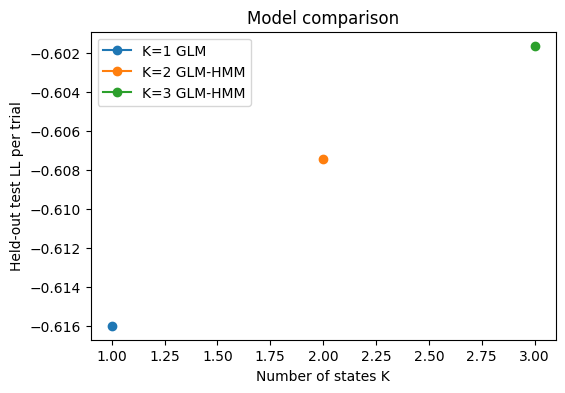

,K,mean_test_ll_per_trial,mean_delta_bits_per_trial_vs_glm,min_delta_bits_per_trial_vs_glm,max_delta_bits_per_trial_vs_glm,mean_train_ll_improvement
0,2,-0.607419,0.012393,-0.006406,0.022452,145.467820
1,3,-0.601606,0.020779,0.005071,0.028687,188.968229


In [16]:
glm_summary = pd.read_csv(RESULTS_DIR / "glm_1state_cv_summary.csv")
hmm_all = pd.read_csv(RESULTS_DIR / "glmhmm_all_fits_summary.csv")
hmm_best = (
    hmm_all.sort_values(["K", "fold", "final_train_ll"], ascending=[True, True, False])
    .groupby(["K", "fold"], as_index=False)
    .first()
)
hmm_best["selected_by"] = "highest_final_train_ll"
hmm_best_path = RESULTS_DIR / "glmhmm_best_by_K_fold.csv"
hmm_best.to_csv(hmm_best_path, index=False)
glm_for_merge = glm_summary[["fold", "test_ll", "test_ll_per_trial", "test_accuracy"]].rename(
    columns={
        "test_ll": "glm_test_ll",
        "test_ll_per_trial": "glm_test_ll_per_trial",
        "test_accuracy": "glm_test_accuracy",
    }
)
comparison = hmm_best.merge(glm_for_merge, on="fold", how="left")
comparison["delta_ll_vs_glm"] = comparison["test_ll"] - comparison["glm_test_ll"]
comparison["delta_bits_per_trial_vs_glm"] = comparison["delta_ll_vs_glm"] / (
    comparison["n_test_trials"] * np.log(2)
)
comparison_path = RESULTS_DIR / "model_comparison_vs_1state_GLM.csv"
comparison.to_csv(comparison_path, index=False)
model_selection_summary = (
    comparison.groupby("K")
    .agg(
        mean_test_ll_per_trial=("test_ll_per_trial", "mean"),
        mean_delta_bits_per_trial_vs_glm=("delta_bits_per_trial_vs_glm", "mean"),
        min_delta_bits_per_trial_vs_glm=("delta_bits_per_trial_vs_glm", "min"),
        max_delta_bits_per_trial_vs_glm=("delta_bits_per_trial_vs_glm", "max"),
        mean_train_ll_improvement=("train_ll_improvement", "mean"),
    )
    .reset_index()
)
plt.figure(figsize=(6, 4))
plt.plot([1], [glm_summary["test_ll_per_trial"].mean()], marker="o", label="K=1 GLM")
for K, sub in comparison.groupby("K"):
    plt.plot([K], [sub["test_ll_per_trial"].mean()], marker="o", label=f"K={K} GLM-HMM")
plt.xlabel("Number of states K")
plt.ylabel("Held-out test LL per trial")
plt.title("Model comparison")
plt.legend()
plt.show()

model_selection_summary

In [17]:
best_by_K_fold_path = RESULTS_DIR / "glmhmm_best_by_K_fold.csv"
if not best_by_K_fold_path.exists():
    raise FileNotFoundError(f"Could not find {best_by_K_fold_path}. Run the preceding model-comparison cells first.")
best_by_K_fold = pd.read_csv(best_by_K_fold_path)


def load_saved_model_params(raw_param_path):
    raw_param_path = Path(raw_param_path)
    if not raw_param_path.exists():
        raise FileNotFoundError(f"Model parameter file not found: {raw_param_path}")
    if raw_param_path.suffix == ".pkl":
        with open(raw_param_path, "rb") as f:
            payload = pickle.load(f)
        if "model_params" in payload:
            params = payload["model_params"]
        elif "hmm_params" in payload:
            params = payload["hmm_params"]
        else:
            raise KeyError("Could not find 'model_params' or 'hmm_params' in pickle.")
        return (params, payload)
    elif raw_param_path.suffix == ".npz":
        container = np.load(raw_param_path, allow_pickle=True)
        if "arr_0" in container.files:
            params = container["arr_0"]
        elif "model_params" in container.files:
            params = container["model_params"]
        elif "hmm_params" in container.files:
            params = container["hmm_params"]
        else:
            raise KeyError(f"No model parameters found. Available keys: {container.files}")
        if isinstance(params, np.ndarray) and params.dtype == object:
            try:
                params = params.item()
            except Exception:
                params = tuple(params.tolist())
        return (params, {"npz_keys": container.files})
    else:
        raise ValueError(f"Unsupported parameter file type: {raw_param_path.suffix}")


def load_best_model(K, fold=None):
    sub = best_by_K_fold[best_by_K_fold["K"] == K].copy()
    if fold is not None:
        sub = sub[sub["fold"] == fold].copy()
    if len(sub) == 0:
        raise ValueError(f"No model found for K={K}, fold={fold}")
    # Use the first fold for the representative model; never choose it by test score.
    best_row = sub.sort_values("fold").iloc[0].to_dict()
    raw_param_path = Path(best_row["raw_param_path"])
    params, payload = load_saved_model_params(raw_param_path)
    M_obs = obs_mat.shape[1]
    M_trans = trans_mat.shape[1]
    model = make_hmm(K, M_obs, M_trans, C=2, D=1, prior_sigma=PRIOR_SIGMA, transition_alpha=TRANSITION_ALPHA)
    model.params = params
    return (model, best_row, payload)


K_TO_INTERPRET = 2
model, best_row, payload = load_best_model(K_TO_INTERPRET)

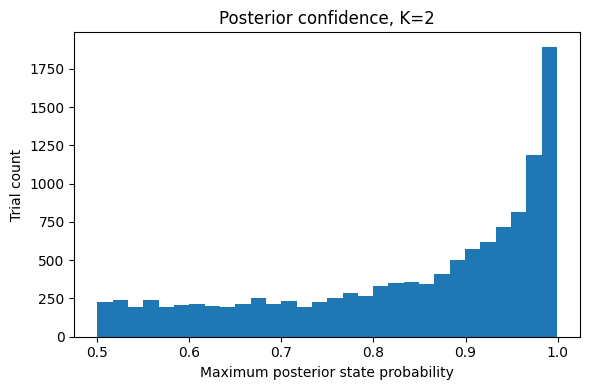

In [18]:
base_df = df_model.copy()
base_df = base_df.reset_index(drop=True)
base_df["global_trial_index"] = np.arange(len(base_df))


def expected_state_probs_one_session(model, data, obs_input, trans_input, mask=None):
    result = model.expected_states(
        data, transition_input=trans_input, observation_input=obs_input, mask=mask
    )
    gamma = result[0] if isinstance(result, tuple) else result
    gamma = np.asarray(gamma)
    if gamma.ndim != 2 or not np.isfinite(gamma).all():
        raise ValueError(f"Expected a finite 2D state posterior, got shape {gamma.shape}")
    return gamma


def decode_all_sessions(model):
    inputs_obs, inputs_trans, datas, masks, session_ids = segment_by_session(
        obs_mat, trans_mat, output, session
    )
    session_array = np.asarray(session).astype(str)
    decoded_rows = []
    for sid, xobs, xtr, yseq, mseq in zip(session_ids, inputs_obs, inputs_trans, datas, masks):
        sid_str = str(sid)
        gamma = expected_state_probs_one_session(
            model=model, data=yseq, obs_input=xobs, trans_input=xtr, mask=mseq
        )
        decoded_state = gamma.argmax(axis=1)
        max_state_prob = gamma.max(axis=1)
        idx = np.where(session_array == sid_str)[0]
        if len(idx) != len(decoded_state):
            raise ValueError(
                f"Decoded session length mismatch for session {sid_str}. Original length={len(idx)}, decoded length={len(decoded_state)}"
            )
        for local_i, global_i in enumerate(idx):
            row = {
                "global_trial_index": int(global_i),
                "session_id": sid_str,
                "decoded_state": int(decoded_state[local_i]),
                "max_state_prob": float(max_state_prob[local_i]),
            }
            for k in range(gamma.shape[1]):
                row[f"p_state_{k}"] = float(gamma[local_i, k])
            decoded_rows.append(row)
    decoded_only = pd.DataFrame(decoded_rows)
    decoded_full = base_df.merge(decoded_only, on=["global_trial_index", "session_id"], how="left")
    return decoded_full


decoded_df = decode_all_sessions(model)
decoded_path = RESULTS_DIR / f"decoded_trials_K{K_TO_INTERPRET}.csv"
decoded_df.to_csv(decoded_path, index=False)
posterior_confidence = decoded_df["max_state_prob"].describe()
plt.figure(figsize=(6, 4))
plt.hist(decoded_df["max_state_prob"].dropna(), bins=30)
plt.xlabel("Maximum posterior state probability")
plt.ylabel("Trial count")
plt.title(f"Posterior confidence, K={K_TO_INTERPRET}")
plt.tight_layout()
fig_path = RESULTS_DIR / f"posterior_confidence_hist_K{K_TO_INTERPRET}.png"
plt.savefig(fig_path, dpi=300)
plt.show()

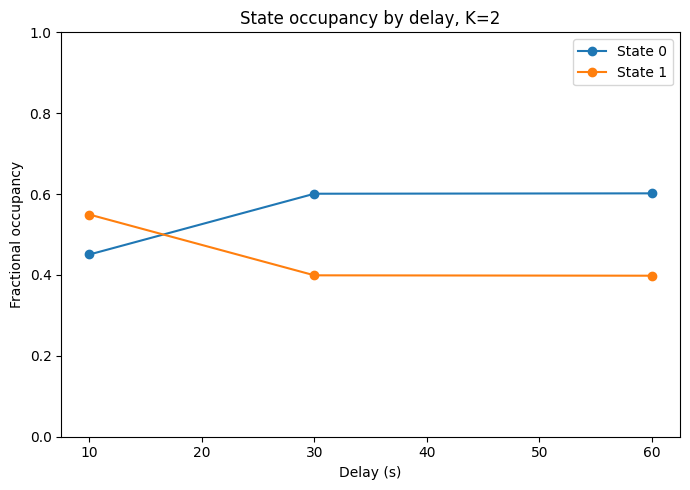

In [19]:
state_summary = (
    decoded_df.dropna(subset=["decoded_state"])
    .groupby("decoded_state")
    .agg(
        n_trials=("decoded_state", "size"),
        mean_accuracy=("trial_correct", "mean"),
        mean_right_choice_rate=("choice_right", "mean"),
        mean_max_state_prob=("max_state_prob", "mean"),
    )
    .reset_index()
)
state_summary["occupancy"] = state_summary["n_trials"] / len(decoded_df)
if "repeat_choice" in decoded_df.columns:
    repeat_summary = (
        decoded_df.dropna(subset=["decoded_state"])
        .groupby("decoded_state")
        .agg(mean_repeat_choice_rate=("repeat_choice", "mean"))
        .reset_index()
    )
    state_summary = state_summary.merge(repeat_summary, on="decoded_state", how="left")
if "prev_reward_signed" in decoded_df.columns:
    reward_summary = (
        decoded_df.dropna(subset=["decoded_state"])
        .groupby("decoded_state")
        .agg(mean_prev_reward=("prev_reward_signed", "mean"))
        .reset_index()
    )
    state_summary = state_summary.merge(reward_summary, on="decoded_state", how="left")


def label_state(row, acc_median):
    acc = row["mean_accuracy"]
    right_rate = row["mean_right_choice_rate"]
    label_parts = []
    if acc >= acc_median:
        label_parts.append("higher-accuracy / rule-following-like")
    else:
        label_parts.append("lower-accuracy / weaker-rule-like")
    if right_rate >= 0.6:
        label_parts.append("right-biased")
    elif right_rate <= 0.4:
        label_parts.append("left-biased")
    else:
        label_parts.append("low side-bias")
    if "mean_repeat_choice_rate" in row.index:
        if pd.notna(row["mean_repeat_choice_rate"]) and row["mean_repeat_choice_rate"] >= 0.6:
            label_parts.append("repeat-choice-like")
    return " + ".join(label_parts)


acc_median = state_summary["mean_accuracy"].median()
state_summary["exploratory_state_label"] = state_summary.apply(
    lambda row: label_state(row, acc_median), axis=1
)
state_summary_path = RESULTS_DIR / f"state_summary_K{K_TO_INTERPRET}.csv"
state_summary.to_csv(state_summary_path, index=False)
occ_delay_counts = (
    decoded_df.dropna(subset=["delay_s", "decoded_state"])
    .groupby(["delay_s", "decoded_state"])
    .size()
    .reset_index(name="n_trials")
)
delay_totals = (
    decoded_df.dropna(subset=["delay_s", "decoded_state"])
    .groupby("delay_s")
    .size()
    .reset_index(name="n_delay_trials")
)
occupancy_by_delay = occ_delay_counts.merge(delay_totals, on="delay_s", how="left")
occupancy_by_delay["fractional_occupancy"] = (
    occupancy_by_delay["n_trials"] / occupancy_by_delay["n_delay_trials"]
)
occupancy_by_delay_path = RESULTS_DIR / f"state_occupancy_by_delay_K{K_TO_INTERPRET}.csv"
occupancy_by_delay.to_csv(occupancy_by_delay_path, index=False)
occupancy_by_mouse_delay_counts = (
    decoded_df.dropna(subset=["mouse_id", "delay_s", "decoded_state"])
    .groupby(["mouse_id", "delay_s", "decoded_state"])
    .size()
    .reset_index(name="n_trials")
)
mouse_delay_totals = (
    decoded_df.dropna(subset=["mouse_id", "delay_s", "decoded_state"])
    .groupby(["mouse_id", "delay_s"])
    .size()
    .reset_index(name="n_mouse_delay_trials")
)
occupancy_by_mouse_delay = occupancy_by_mouse_delay_counts.merge(
    mouse_delay_totals, on=["mouse_id", "delay_s"], how="left"
)
occupancy_by_mouse_delay["fractional_occupancy"] = (
    occupancy_by_mouse_delay["n_trials"] / occupancy_by_mouse_delay["n_mouse_delay_trials"]
)
occupancy_by_mouse_delay_path = RESULTS_DIR / f"state_occupancy_by_mouse_delay_K{K_TO_INTERPRET}.csv"
occupancy_by_mouse_delay.to_csv(occupancy_by_mouse_delay_path, index=False)
plt.figure(figsize=(7, 5))
for st in sorted(occupancy_by_delay["decoded_state"].unique()):
    sub = occupancy_by_delay[occupancy_by_delay["decoded_state"] == st]
    plt.plot(sub["delay_s"], sub["fractional_occupancy"], marker="o", label=f"State {st}")
plt.xlabel("Delay (s)")
plt.ylabel("Fractional occupancy")
plt.title(f"State occupancy by delay, K={K_TO_INTERPRET}")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
fig_path = RESULTS_DIR / f"state_occupancy_by_delay_K{K_TO_INTERPRET}.png"
plt.savefig(fig_path, dpi=300)
plt.show()

/tmp/ipykernel_985/493055258.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=[f"State {st}" for st in states])


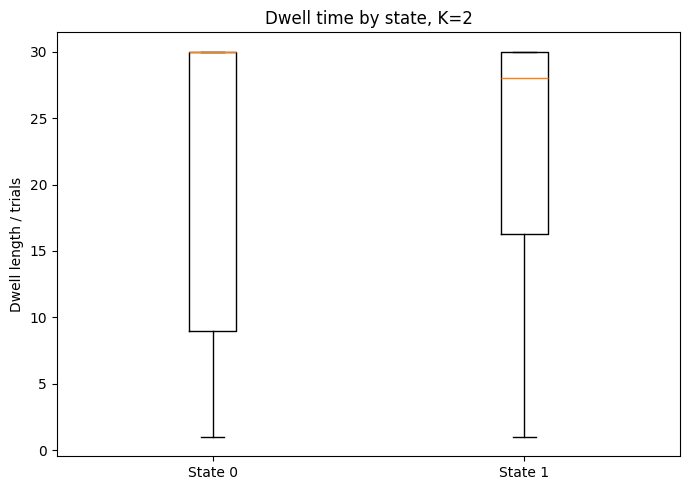

In [20]:
def dwell_lengths(states):
    states = np.asarray(states)
    states = states[~pd.isna(states)]
    if len(states) == 0:
        return []
    states = states.astype(int)
    lengths = []
    current = states[0]
    count = 1
    for s in states[1:]:
        if s == current:
            count += 1
        else:
            lengths.append((int(current), int(count)))
            current = s
            count = 1
    lengths.append((int(current), int(count)))
    return lengths


switch_summary, dwell_summary = summarize_early_switches(K_TO_INTERPRET, RESULTS_DIR, decoded_df)

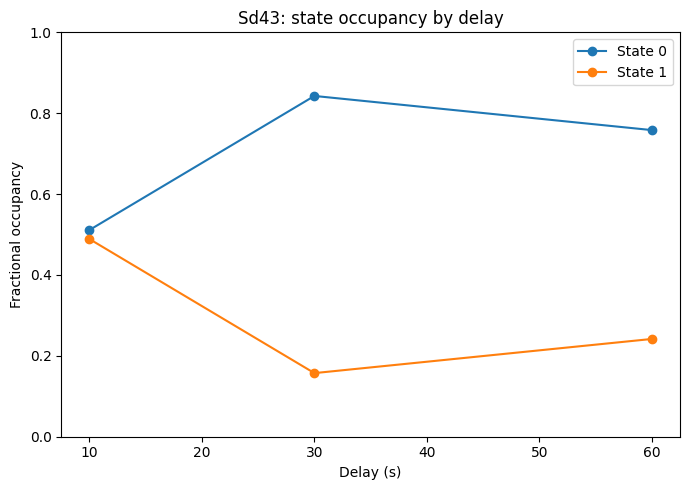

In [21]:
if "state_summary" in globals():
    if "exploratory_state_label" in state_summary.columns:
        state_label_table = state_summary[["decoded_state", "exploratory_state_label"]].copy()
    else:
        state_label_table = state_summary[["decoded_state"]].copy()
        state_label_table["exploratory_state_label"] = "exploratory state " + state_label_table[
            "decoded_state"
        ].astype(str)
else:
    state_label_table = pd.DataFrame({"decoded_state": sorted(decoded_df["decoded_state"].dropna().unique())})
    state_label_table["exploratory_state_label"] = "exploratory state " + state_label_table[
        "decoded_state"
    ].astype(int).astype(str)


def get_dwell_table_for_mouse(mouse_df):
    dwell_rows = []
    for sid, sub in mouse_df.sort_values(["session_id", "trial_in_session"]).groupby(
        "session_id", sort=False
    ):
        states = sub["decoded_state"].dropna().astype(int).to_numpy()
        if len(states) == 0:
            continue
        current_state = states[0]
        dwell_len = 1
        for s in states[1:]:
            if s == current_state:
                dwell_len += 1
            else:
                dwell_rows.append(
                    {"session_id": sid, "decoded_state": int(current_state), "dwell_trials": int(dwell_len)}
                )
                current_state = s
                dwell_len = 1
        dwell_rows.append(
            {"session_id": sid, "decoded_state": int(current_state), "dwell_trials": int(dwell_len)}
        )
    return pd.DataFrame(dwell_rows)


def mouse_strategy_report(mouse_id, decoded_df, min_occupancy=0.1, min_median_dwell=3):
    mouse_df = decoded_df[decoded_df["mouse_id"].astype(str) == str(mouse_id)].copy()
    if len(mouse_df) == 0:
        available = sorted(decoded_df["mouse_id"].astype(str).unique())
        raise ValueError(f"Mouse {mouse_id} not found. Available examples: {available[:10]}")
    occ = (
        mouse_df.dropna(subset=["decoded_state"])
        .groupby("decoded_state")
        .agg(
            n_trials=("decoded_state", "size"),
            mean_accuracy=("trial_correct", "mean"),
            mean_right_choice_rate=("choice_right", "mean"),
            mean_max_state_prob=("max_state_prob", "mean"),
        )
        .reset_index()
    )
    occ["occupancy"] = occ["n_trials"] / len(mouse_df)
    dwell_mouse = get_dwell_table_for_mouse(mouse_df)
    if len(dwell_mouse) > 0:
        dwell_stats = (
            dwell_mouse.groupby("decoded_state")
            .agg(
                median_dwell_trials=("dwell_trials", "median"),
                mean_dwell_trials=("dwell_trials", "mean"),
                max_dwell_trials=("dwell_trials", "max"),
            )
            .reset_index()
        )
        occ = occ.merge(dwell_stats, on="decoded_state", how="left")
    else:
        occ["median_dwell_trials"] = np.nan
        occ["mean_dwell_trials"] = np.nan
        occ["max_dwell_trials"] = np.nan
    occ = occ.merge(state_label_table, on="decoded_state", how="left")
    occ["passes_occupancy"] = occ["occupancy"] >= min_occupancy
    occ["passes_dwell"] = occ["median_dwell_trials"] >= min_median_dwell
    occ["counts_as_used_strategy"] = occ["passes_occupancy"] & occ["passes_dwell"]
    estimated_n_strategies = int(occ["counts_as_used_strategy"].sum())
    mouse_delay_counts = (
        mouse_df.dropna(subset=["delay_s", "decoded_state"])
        .groupby(["delay_s", "decoded_state"])
        .size()
        .reset_index(name="n_trials")
    )
    delay_totals = (
        mouse_df.dropna(subset=["delay_s", "decoded_state"])
        .groupby("delay_s")
        .size()
        .reset_index(name="n_delay_trials")
    )
    mouse_delay_occ = mouse_delay_counts.merge(delay_totals, on="delay_s", how="left")
    mouse_delay_occ["fractional_occupancy"] = mouse_delay_occ["n_trials"] / mouse_delay_occ["n_delay_trials"]
    plt.figure(figsize=(7, 5))
    for st in sorted(mouse_delay_occ["decoded_state"].unique()):
        sub = mouse_delay_occ[mouse_delay_occ["decoded_state"] == st]
        plt.plot(sub["delay_s"], sub["fractional_occupancy"], marker="o", label=f"State {int(st)}")
    plt.xlabel("Delay (s)")
    plt.ylabel("Fractional occupancy")
    plt.title(f"{mouse_id}: state occupancy by delay")
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()
    return (occ, mouse_delay_occ, estimated_n_strategies)


MOUSE_TO_REPORT = "Sd43"
if MOUSE_TO_REPORT not in decoded_df["mouse_id"].astype(str).unique():
    MOUSE_TO_REPORT = sorted(decoded_df["mouse_id"].astype(str).unique())[0]
mouse_occ, mouse_delay_occ, estimated_n_strategies = mouse_strategy_report(
    MOUSE_TO_REPORT, decoded_df, min_occupancy=0.1, min_median_dwell=3
)

In [22]:
all_mouse_reports = summarize_mouse_strategies(K_TO_INTERPRET, RESULTS_DIR, decoded_df)

#### 3. Balanced folds

In [23]:
PROJECT_DIR = OUTPUT_ROOT / "01_balanced"
DATA_DIR = PROJECT_DIR
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CLEAN_CSV_PATH = INPUT_DIR / "trials_clean.csv"
CSV_CANDIDATES = [CLEAN_CSV_PATH]
CSV_FILENAME = CLEAN_CSV_PATH.name
RANDOM_SEED = 0
CV_SCHEME = "balanced_mouse_delay_3fold"
N_FOLDS = 3
TAU = 4.0
K_LIST = [2, 3]
QUICK_RUN = True
if QUICK_RUN:
    N_INITS = 3
    N_EM_ITERS = 100
else:
    N_INITS = 10
    N_EM_ITERS = 300
PRIOR_SIGMA = 100.0
TRANSITION_ALPHA = 1.0
INIT_NOISE_SCALE = 0.15

In [24]:
for candidate in CSV_CANDIDATES:
    if candidate.exists():
        CLEAN_CSV_PATH = candidate
        break
else:
    raise FileNotFoundError(
        f"Could not find the clean CSV. Put working_memory_long_format_clean(2).csv in:\n  {PROJECT_DIR}\nor upload it to the current runtime."
    )
df_long = pd.read_csv(CLEAN_CSV_PATH)
if "session_date" in df_long.columns:
    df_long["session_date"] = pd.to_datetime(df_long["session_date"], errors="coerce")
elif "session_date_raw" in df_long.columns:
    df_long["session_date"] = pd.to_datetime(
        df_long["session_date_raw"], unit="D", origin="1899-12-30", errors="coerce"
    )
else:
    df_long["session_date"] = pd.NaT
numeric_cols = [
    "testing_num",
    "delay_from_label",
    "session_index",
    "trial_in_session",
    "delay_s",
    "correct_cumulative_original",
    "choice_right",
    "sample_right",
    "correct_side_right",
    "trial_correct",
]
for col in numeric_cols:
    if col in df_long.columns:
        df_long[col] = pd.to_numeric(df_long[col], errors="coerce")
for col in ["sample_side", "choice"]:
    if col in df_long.columns:
        df_long[col] = df_long[col].astype(str).str.lower().str.strip()
required_cols = ["mouse_id", "session_id", "trial_in_session", "delay_s", "sample_side", "choice"]
missing = [c for c in required_cols if c not in df_long.columns]
if missing:
    raise ValueError(f"Missing required columns in clean CSV: {missing}")
standardized_csv_path = RESULTS_DIR / "working_memory_long_format_clean_standardized.csv"
df_long.to_csv(standardized_csv_path, index=False)

In [25]:
df_model = df_long.copy()
for col in ["sample_side", "choice"]:
    df_model[col] = df_model[col].astype(str).str.lower().str.strip()
valid_sides = {"left", "right"}
bad_sample = df_model.loc[~df_model["sample_side"].isin(valid_sides)]
bad_choice = df_model.loc[~df_model["choice"].isin(valid_sides)]
if len(bad_sample) > 0:
    raise ValueError("Some sample/order values are not left/right.")
if len(bad_choice) > 0:
    raise ValueError("Some choice values are not left/right.")
sort_cols = [
    c
    for c in ["mouse_id", "session_date", "testing_num", "session_index", "trial_in_session"]
    if c in df_model.columns
]
df_model = df_model.sort_values(sort_cols).reset_index(drop=True)
validate_source_trial_columns(df_model)
for rule_col in ["correct_side_right", "trial_correct"]:
    if rule_col not in df_model.columns:
        raise ValueError(f"Missing original task-rule column: {rule_col}")
original_correct_side_right = pd.to_numeric(df_model["correct_side_right"], errors="raise").to_numpy()
original_trial_correct = pd.to_numeric(df_model["trial_correct"], errors="raise").to_numpy()
assert np.isin(original_correct_side_right, [0, 1]).all(), "Original correct_side_right must be binary."
assert np.isin(original_trial_correct, [0, 1]).all(), "Original trial_correct must be binary."
df_model["choice_right"] = (df_model["choice"] == "right").astype(int)
df_model["sample_right"] = (df_model["sample_side"] == "right").astype(int)
df_model["choice_signed"] = df_model["choice_right"] * 2 - 1
df_model["sample_signed"] = df_model["sample_right"] * 2 - 1
df_model["correct_side_signed"] = -df_model["sample_signed"]
df_model["correct_side_right"] = (df_model["correct_side_signed"] == 1).astype(int)
df_model["trial_correct"] = (df_model["choice_signed"] == df_model["correct_side_signed"]).astype(int)
df_model["reward_signed"] = df_model["trial_correct"] * 2 - 1
assert np.array_equal(
    df_model["correct_side_right"].to_numpy(), original_correct_side_right
), "Derived non-match rule disagrees with original correct_side_right."
assert np.array_equal(
    df_model["trial_correct"].to_numpy(), original_trial_correct
), "Derived non-match rule disagrees with original trial_correct."
df_model["derived_correct_cumulative"] = df_model.groupby("session_id")["trial_correct"].cumsum()
cumulative_mismatch = get_recorded_cumulative_mismatch(df_model, RESULTS_DIR)
assert not cumulative_mismatch.any(), (
    f"Task-rule validation failed: {int(cumulative_mismatch.sum())} rows disagree with "
    "recorded cumulative correctness. Review task_rule_cumulative_mismatches.csv "
    "against source records before refitting. No discrepancies are waived."
)
summary_by_delay = (
    df_model.groupby("delay_s")
    .agg(
        n_trials=("trial_correct", "size"),
        accuracy=("trial_correct", "mean"),
        p_right_choice=("choice_right", "mean"),
        p_right_correct_side=("correct_side_right", "mean"),
    )
    .reset_index()
)

In [26]:
df_model = add_prev_within_session(df_model, "choice_signed", "prev_choice_signed")
df_model = add_prev_within_session(df_model, "correct_side_signed", "prev_correct_side_signed")
df_model = add_prev_within_session(df_model, "reward_signed", "prev_reward_signed")
df_model = exponential_filter_by_session(df_model, "prev_choice_signed", "filt_prev_choice", tau=TAU)
df_model = exponential_filter_by_session(
    df_model, "prev_correct_side_signed", "filt_prev_correct_side", tau=TAU
)
df_model = exponential_filter_by_session(df_model, "prev_reward_signed", "filt_prev_reward", tau=TAU)
df_model = add_temporal_bases(df_model)
df_model["delay_z"] = zscore(df_model["delay_s"])
df_model["correct_side_x_delay_z"] = df_model["correct_side_signed"] * df_model["delay_z"]
assert np.allclose(
    df_model["prev_correct_side_signed"],
    df_model["prev_choice_signed"] * df_model["prev_reward_signed"],
), "prev_correct_side_signed must equal prev_choice_signed * prev_reward_signed."
obs_regressor_names = [
    "correct_side_signed",
    "prev_choice_signed",
    "prev_reward_signed",
    "prev_correct_side_signed",  # win-stay/lose-switch: prev_choice_signed * prev_reward_signed
    "delay_z",
    "correct_side_x_delay_z",
    "obs_bias",
]
df_model["obs_bias"] = 1.0
trans_regressor_names = [
    "filt_prev_choice",
    "filt_prev_correct_side",
    "filt_prev_reward",
    "delay_z",
    "basis_early",
    "basis_middle",
    "basis_late",
    "trans_bias",
]
df_model["trans_bias"] = 1.0
obs_mat = df_model[obs_regressor_names].to_numpy(dtype=float)
trans_mat = df_model[trans_regressor_names].to_numpy(dtype=float)
output = df_model["choice_right"].to_numpy(dtype=int).reshape(-1, 1)
session = df_model["session_id"].astype(str).to_numpy()
assert obs_mat.shape[0] == trans_mat.shape[0] == output.shape[0] == session.shape[0]
assert set(np.unique(output[:, 0])).issubset({0, 1})
assert np.isfinite(obs_mat).all()
assert np.isfinite(trans_mat).all()

In [27]:
rng = np.random.default_rng(RANDOM_SEED)
session_info = make_session_info_for_folds(df_model)
mouse_delay_counts = (
    session_info.groupby(["mouse_id", "delay_s"])["session_id"]
    .nunique()
    .reset_index(name="n_sessions")
    .sort_values(["n_sessions", "mouse_id", "delay_s"])
)
if CV_SCHEME == "balanced_mouse_delay_3fold":
    N_FOLDS = 3
    fold_records = []
    unique_delays = sorted(session_info["delay_s"].dropna().unique())
    fold_delay_counts = {fold: {delay: 0 for delay in unique_delays} for fold in range(N_FOLDS)}
    for (mouse_id, delay_s), sub in session_info.groupby(["mouse_id", "delay_s"], sort=False):
        sess = sub["session_id"].to_numpy().copy()
        rng.shuffle(sess)
        used_folds_for_this_mouse_delay = set()
        for sid in sess:
            candidate_folds = [f for f in range(N_FOLDS) if f not in used_folds_for_this_mouse_delay]
            if len(candidate_folds) == 0:
                candidate_folds = list(range(N_FOLDS))
            min_load = min((fold_delay_counts[f][delay_s] for f in candidate_folds))
            best_folds = [f for f in candidate_folds if fold_delay_counts[f][delay_s] == min_load]
            chosen_fold = int(rng.choice(best_folds))
            fold_records.append([sid, chosen_fold])
            used_folds_for_this_mouse_delay.add(chosen_fold)
            fold_delay_counts[chosen_fold][delay_s] += 1
else:
    fold_records = []
    for mouse_id, sub in session_info.groupby("mouse_id", sort=False):
        sess = sub["session_id"].to_numpy().copy()
        rng.shuffle(sess)
        for i, sid in enumerate(sess):
            fold_records.append([sid, i % N_FOLDS])
fold_mapping_session = np.array(fold_records, dtype=object)
assert len(fold_mapping_session) == df_model["session_id"].nunique()
assert len(np.unique(fold_mapping_session[:, 0])) == len(fold_mapping_session), (
    "Each complete session must be assigned to exactly one fold."
)
fold_df = pd.DataFrame(fold_mapping_session, columns=["session_id", "fold"])
fold_df["fold"] = fold_df["fold"].astype(int)
fold_diag = (
    session_info.merge(fold_df, on="session_id", how="left")
    .groupby(["fold", "delay_s"])
    .size()
    .reset_index(name="n_sessions")
)
n_missing = fold_df["fold"].isna().sum()
n_duplicate_sessions = fold_df["session_id"].duplicated().sum()
if n_missing > 0:
    raise ValueError("Some sessions do not have fold assignments.")
if n_duplicate_sessions > 0:
    raise ValueError("Some sessions were assigned to more than one fold.")
np.savez(DATA_DIR / "combined_all_mice.npz", obs_mat, trans_mat, output, session)
np.savez(DATA_DIR / "fold_mapping_session_all_mice.npz", fold_mapping_session)
np.savez(
    DATA_DIR / "regressor_names.npz",
    obs_regressor_names=np.array(obs_regressor_names),
    trans_regressor_names=np.array(trans_regressor_names),
)
df_model.to_csv(DATA_DIR / "working_memory_model_ready_metadata.csv", index=False)
fold_df.to_csv(RESULTS_DIR / "fold_mapping_session.csv", index=False)

In [28]:
def segment_by_session(obs_array, trans_array, y_array, session_array):
    obs_array = np.asarray(obs_array, dtype=float)
    trans_array = np.asarray(trans_array, dtype=float)
    y_array = np.asarray(y_array)
    session_array = np.asarray(session_array).astype(str)
    if y_array.ndim == 1:
        y_array = y_array.reshape(-1, 1)
    if not len(obs_array) == len(trans_array) == len(y_array) == len(session_array):
        raise ValueError("obs, trans, y, and session arrays must have the same length.")
    obs_inputs, trans_inputs, datas, masks, session_ids = ([], [], [], [], [])
    tmp = pd.DataFrame({"row_index": np.arange(len(session_array)), "session_id": session_array})
    for sid, sub in tmp.groupby("session_id", sort=False):
        idx = sub["row_index"].to_numpy()
        obs_inputs.append(obs_array[idx])
        trans_inputs.append(trans_array[idx])
        datas.append(y_array[idx])
        masks.append(np.ones_like(y_array[idx], dtype=bool))
        session_ids.append(str(sid))
    return (obs_inputs, trans_inputs, datas, masks, session_ids)


def check_session_segmentation():
    obs_inputs, trans_inputs, datas, masks, session_ids = segment_by_session(
        obs_mat, trans_mat, output, session
    )
    lengths = pd.Series([len(d) for d in datas], name="n_trials_per_sequence")
    if len(session_ids) != len(np.unique(session)):
        raise ValueError("Session segmentation problem: sequence count does not match unique sessions.")
    return lengths


_ = check_session_segmentation()

In [29]:
X_obs = obs_mat.copy()
y = output[:, 0].astype(int)
glm_summary_rows = []
for fold in range(N_FOLDS):
    train_sessions = fold_mapping_session[fold_mapping_session[:, 1].astype(int) != fold, 0].astype(str)
    test_sessions = fold_mapping_session[fold_mapping_session[:, 1].astype(int) == fold, 0].astype(str)
    train_idx = np.isin(session, train_sessions)
    test_idx = np.isin(session, test_sessions)
    X_train, y_train = (X_obs[train_idx], y[train_idx])
    X_test, y_test = (X_obs[test_idx], y[test_idx])
    w_hat, train_ll, opt = fit_logistic_glm(X_train, y_train, prior_sigma=PRIOR_SIGMA)
    test_ll, test_acc = eval_logistic_glm(w_hat, X_test, y_test)
    p_right_train = np.clip(np.mean(y_train), 1e-09, 1 - 1e-09)
    baseline_test_ll = np.sum(y_test * np.log(p_right_train) + (1 - y_test) * np.log(1 - p_right_train))
    bits_over_baseline = (test_ll - baseline_test_ll) / (len(y_test) * np.log(2))
    fold_dir = RESULTS_DIR / "Model" / "glm_#state=1" / f"fld_num={fold}"
    fold_dir.mkdir(parents=True, exist_ok=True)
    glm_weights_for_hmm = w_hat.reshape(1, 1, -1)
    np.savez(fold_dir / "important_params_iter_0.npz", train_ll, glm_weights_for_hmm)
    glm_summary_rows.append(
        {
            "K": 1,
            "fold": fold,
            "n_train_trials": int(train_idx.sum()),
            "n_test_trials": int(test_idx.sum()),
            "train_ll": float(train_ll),
            "test_ll": float(test_ll),
            "test_ll_per_trial": float(test_ll / len(y_test)),
            "test_accuracy": float(test_acc),
            "baseline_test_ll": float(baseline_test_ll),
            "bits_per_trial_over_baseline": float(bits_over_baseline),
            **{f"w_{name}": float(val) for name, val in zip(obs_regressor_names, w_hat)},
        }
    )
glm_summary = pd.DataFrame(glm_summary_rows)
glm_summary_path = RESULTS_DIR / "glm_1state_cv_summary.csv"
glm_summary.to_csv(glm_summary_path, index=False)

In [30]:
def fit_one_glmhmm(K, fold, iter_id, num_iters=N_EM_ITERS):
    train_sessions = fold_mapping_session[fold_mapping_session[:, 1].astype(int) != fold, 0].astype(str)
    test_sessions = fold_mapping_session[fold_mapping_session[:, 1].astype(int) == fold, 0].astype(str)
    train_idx = np.isin(session, train_sessions)
    test_idx = np.isin(session, test_sessions)
    obs_train = obs_mat[train_idx]
    trans_train = trans_mat[train_idx]
    y_train = output[train_idx]
    session_train = session[train_idx]
    obs_test = obs_mat[test_idx]
    trans_test = trans_mat[test_idx]
    y_test = output[test_idx]
    session_test = session[test_idx]
    inputs_train, inputs_trans_train, datas_train, masks_train, session_ids_train = segment_by_session(
        obs_train, trans_train, y_train, session_train
    )
    inputs_test, inputs_trans_test, datas_test, masks_test, session_ids_test = segment_by_session(
        obs_test, trans_test, y_test, session_test
    )
    M_obs = obs_mat.shape[1]
    M_trans = trans_mat.shape[1]
    glm_init_path = RESULTS_DIR / "Model" / "glm_#state=1" / f"fld_num={fold}" / "important_params_iter_0.npz"
    glm_container = np.load(glm_init_path, allow_pickle=True)
    glm_weights = glm_container["arr_1"]
    np.random.seed(RANDOM_SEED + 10000 * K + 100 * fold + iter_id)
    model = make_hmm(K, M_obs, M_trans, C=2, D=1, prior_sigma=PRIOR_SIGMA, transition_alpha=TRANSITION_ALPHA)
    model = initialize_hmm_from_glm(model, glm_weights, K=K, seed=iter_id, noise_scale=INIT_NOISE_SCALE)
    print(
        f"Fitting K={K}, fold={fold}, init={iter_id}, train sessions={len(session_ids_train)}, test sessions={len(session_ids_test)}"
    )
    initial_train_ll = hmm_log_probability(
        model, datas_train, inputs_train, inputs_trans_train, masks_train
    )
    lls = model.fit(
        datas_train,
        transition_input=inputs_trans_train,
        observation_input=inputs_train,
        masks=masks_train,
        method="em",
        num_iters=num_iters,
        initialize=False,
        tolerance=0.0001,
    )
    # EM history contains a regularized, lagged objective; score final parameters directly.
    final_train_ll = hmm_log_probability(
        model, datas_train, inputs_train, inputs_trans_train, masks_train
    )
    if not np.isfinite(final_train_ll):
        raise ValueError("Non-finite final training likelihood.")
    test_ll = hmm_log_probability_strict(model, datas_test, inputs_test, inputs_trans_test, masks_test)
    test_ll = float(np.asarray(test_ll))
    test_n = int(y_test.shape[0])
    train_n = int(y_train.shape[0])
    p_right_train = np.clip(np.mean(y_train[:, 0]), 1e-09, 1 - 1e-09)
    baseline_test_ll = np.sum(
        y_test[:, 0] * np.log(p_right_train) + (1 - y_test[:, 0]) * np.log(1 - p_right_train)
    )
    bits_over_baseline = (test_ll - baseline_test_ll) / (test_n * np.log(2))
    save_dir = RESULTS_DIR / "Model" / f"glmhmm_#state={K}" / f"fld_num={fold}" / f"iter_{iter_id}"
    save_dir.mkdir(parents=True, exist_ok=True)
    raw_param_path = save_dir / f"glm_hmm_raw_parameters_itr_{iter_id}.pkl"
    save_payload = {
        "K": K,
        "fold": fold,
        "iter_id": iter_id,
        "model_params": model.params,
        "init_state_distn_params": model.init_state_distn.params,
        "transition_params": model.transitions.params,
        "observation_params": model.observations.params,
        "lls": np.asarray(lls, dtype=float),  # Regularized EM trace.
        "final_train_ll": float(final_train_ll),
        "obs_regressor_names": list(obs_regressor_names),
        "trans_regressor_names": list(trans_regressor_names),
        "train_session_ids": list(session_ids_train),
        "test_session_ids": list(session_ids_test),
        "n_train_trials": train_n,
        "n_test_trials": test_n,
        "test_ll": test_ll,
        "baseline_test_ll": float(baseline_test_ll),
        "bits_per_trial_over_baseline": float(bits_over_baseline),
    }
    with open(raw_param_path, "wb") as f:
        pickle.dump(save_payload, f)
    lls_path = save_dir / f"glm_hmm_lls_itr_{iter_id}.npy"
    np.save(lls_path, np.asarray(lls, dtype=float))
    row = {
        "K": K,
        "fold": fold,
        "iter": iter_id,
        "n_train_trials": train_n,
        "n_test_trials": test_n,
        "n_train_sessions": len(session_ids_train),
        "n_test_sessions": len(session_ids_test),
        "initial_train_ll": float(initial_train_ll),
        "final_train_ll": float(final_train_ll),
        "train_ll_improvement": float(final_train_ll - initial_train_ll),
        "test_ll": float(test_ll),
        "test_ll_per_trial": float(test_ll / test_n),
        "baseline_test_ll": float(baseline_test_ll),
        "bits_per_trial_over_baseline": float(bits_over_baseline),
        "raw_param_path": str(raw_param_path),
        "lls_path": str(lls_path),
    }
    return row

In [31]:
def initialize_hmm_from_glm(model, glm_weights, K, seed=0, noise_scale=0.15, zero_transition_weights=True):
    rng = np.random.default_rng(seed)
    if glm_weights.ndim == 1:
        glm_weights = glm_weights.reshape(1, 1, -1)
    if glm_weights.shape[1] != 1:
        glm_weights = glm_weights[:, 1:2, :]
    # ssm weights describe class 0 (left); the GLM describes class 1 (right).
    obs_init = np.tile(-glm_weights, (K, 1, 1))
    obs_init = obs_init + rng.normal(0, noise_scale, size=obs_init.shape)
    model.observations.params = obs_init
    if zero_transition_weights:
        model.transitions.params[1][...] = np.zeros_like(model.transitions.params[1])
    return model


def hmm_log_probability_strict(model, datas, obs_inputs, trans_inputs, masks=None):
    """Data log-likelihood only; retain the historical helper name for callers."""
    return float(
        np.asarray(
            model.log_likelihood(
                datas, transition_input=trans_inputs, observation_input=obs_inputs, masks=masks
            )
        ).sum()
    )


hmm_log_probability = hmm_log_probability_strict


def expected_state_probs_one_session(model, data, obs_input, trans_input, mask=None):
    result = model.expected_states(
        data, transition_input=trans_input, observation_input=obs_input, mask=mask
    )
    gamma = result[0] if isinstance(result, tuple) else result
    gamma = np.asarray(gamma)
    if gamma.ndim != 2 or not np.isfinite(gamma).all():
        raise ValueError(f"Expected a finite 2D state posterior, got shape {gamma.shape}")
    return gamma


def get_observation_weight_matrix(model):
    """Return interpretation weights for log-odds of right choice; do not alter the model."""
    params = np.asarray(model.observations.params)
    if params.ndim == 3 and params.shape[1] == 1:
        return -params[:, 0, :]
    elif params.ndim == 2:
        return -params
    else:
        raise ValueError(f"Unexpected binary observation parameter shape: {params.shape}")


def get_transition_weight_array(model, K, M_trans):
    """Expand inputdrivenalt destination effects to the existing export layout."""
    params = model.transitions.params
    if not isinstance(params, (list, tuple)) or len(params) != 2:
        raise ValueError("Expected inputdrivenalt parameters [log_Ps, Ws].")
    weights = np.asarray(params[1])
    if weights.shape == (K - 1, M_trans):
        weights = np.vstack([weights, np.zeros((1, M_trans))])
    if weights.shape == (K, M_trans):
        # Effects are shared across source states, relative to the reference destination.
        return np.broadcast_to(weights[None, :, :], (K, K, M_trans)).copy()
    if weights.shape == (K, K, M_trans):
        return weights
    raise ValueError(f"Unexpected transition weight shape: {weights.shape}")


In [32]:
all_hmm_rows = []
for K in K_LIST:
    for fold in range(N_FOLDS):
        for iter_id in range(N_INITS):
            row = fit_one_glmhmm(K=K, fold=fold, iter_id=iter_id, num_iters=N_EM_ITERS)
            all_hmm_rows.append(row)
            running = pd.DataFrame(all_hmm_rows)
            running_path = RESULTS_DIR / "glmhmm_all_fits_running_summary.csv"
            running.to_csv(running_path, index=False)
hmm_all = pd.DataFrame(all_hmm_rows)
hmm_all_path = RESULTS_DIR / "glmhmm_all_fits_summary.csv"
hmm_all.to_csv(hmm_all_path, index=False)

Fitting K=2, fold=0, init=0, train sessions=270, test sessions=135


  0%|          | 0/100 [00:00<?, ?it/s]

Fitting K=2, fold=0, init=1, train sessions=270, test sessions=135


  0%|          | 0/100 [00:00<?, ?it/s]

Fitting K=2, fold=0, init=2, train sessions=270, test sessions=135


...

  0%|          | 0/100 [00:00<?, ?it/s]

Fitting K=3, fold=2, init=1, train sessions=270, test sessions=135


  0%|          | 0/100 [00:00<?, ?it/s]

Fitting K=3, fold=2, init=2, train sessions=270, test sessions=135


  0%|          | 0/100 [00:00<?, ?it/s]

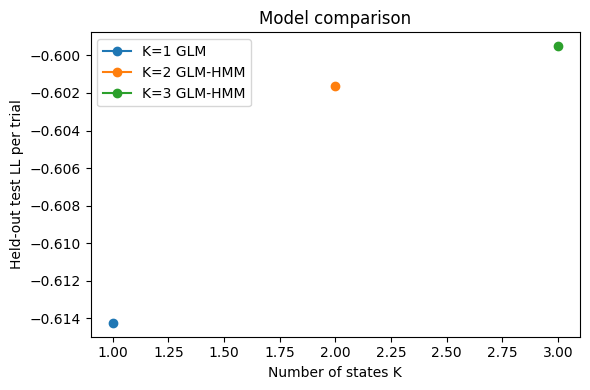

,K,mean_test_ll_per_trial,mean_delta_bits_per_trial_vs_glm,min_delta_bits_per_trial_vs_glm,max_delta_bits_per_trial_vs_glm,mean_train_ll_improvement
0,2,-0.601623,0.018218,0.014722,0.020335,153.650859
1,3,-0.599505,0.021274,0.018877,0.024040,168.909456


In [33]:
glm_summary = pd.read_csv(RESULTS_DIR / "glm_1state_cv_summary.csv")
hmm_all = pd.read_csv(RESULTS_DIR / "glmhmm_all_fits_summary.csv")
hmm_best = (
    hmm_all.sort_values(["K", "fold", "final_train_ll"], ascending=[True, True, False])
    .groupby(["K", "fold"], as_index=False)
    .first()
)
hmm_best["selected_by"] = "highest_final_train_ll"
hmm_best_path = RESULTS_DIR / "glmhmm_best_by_K_fold.csv"
hmm_best.to_csv(hmm_best_path, index=False)
glm_for_merge = glm_summary[["fold", "test_ll", "test_ll_per_trial", "test_accuracy"]].rename(
    columns={
        "test_ll": "glm_test_ll",
        "test_ll_per_trial": "glm_test_ll_per_trial",
        "test_accuracy": "glm_test_accuracy",
    }
)
comparison = hmm_best.merge(glm_for_merge, on="fold", how="left")
comparison["delta_ll_vs_glm"] = comparison["test_ll"] - comparison["glm_test_ll"]
comparison["delta_bits_per_trial_vs_glm"] = comparison["delta_ll_vs_glm"] / (
    comparison["n_test_trials"] * np.log(2)
)
comparison_path = RESULTS_DIR / "model_comparison_vs_1state_GLM.csv"
comparison.to_csv(comparison_path, index=False)
model_selection_summary = (
    comparison.groupby("K")
    .agg(
        mean_test_ll_per_trial=("test_ll_per_trial", "mean"),
        mean_delta_bits_per_trial_vs_glm=("delta_bits_per_trial_vs_glm", "mean"),
        min_delta_bits_per_trial_vs_glm=("delta_bits_per_trial_vs_glm", "min"),
        max_delta_bits_per_trial_vs_glm=("delta_bits_per_trial_vs_glm", "max"),
        mean_train_ll_improvement=("train_ll_improvement", "mean"),
    )
    .reset_index()
)
model_selection_path = RESULTS_DIR / "model_selection_summary.csv"
model_selection_summary.to_csv(model_selection_path, index=False)
plt.figure(figsize=(6, 4))
plt.plot([1], [glm_summary["test_ll_per_trial"].mean()], marker="o", label="K=1 GLM")
for K, sub in comparison.groupby("K"):
    plt.plot([K], [sub["test_ll_per_trial"].mean()], marker="o", label=f"K={K} GLM-HMM")
plt.xlabel("Number of states K")
plt.ylabel("Held-out test LL per trial")
plt.title("Model comparison")
plt.legend()
plt.tight_layout()
fig_path = RESULTS_DIR / "model_comparison_test_ll_per_trial.png"
plt.savefig(fig_path, dpi=300)
plt.show()

model_selection_summary

In [34]:
best_by_K_fold_path = RESULTS_DIR / "glmhmm_best_by_K_fold.csv"
if not best_by_K_fold_path.exists():
    raise FileNotFoundError(f"Could not find {best_by_K_fold_path}. Run the preceding model-comparison cells first.")
best_by_K_fold = pd.read_csv(best_by_K_fold_path)


def load_saved_model_params(raw_param_path):
    raw_param_path = Path(raw_param_path)
    if not raw_param_path.exists():
        raise FileNotFoundError(f"Model parameter file not found: {raw_param_path}")
    with open(raw_param_path, "rb") as f:
        payload = pickle.load(f)
    if "model_params" not in payload:
        raise KeyError("Could not find 'model_params' in pickle.")
    return (payload["model_params"], payload)


def reconstruct_model_from_row(row):
    K = int(row["K"])
    M_obs = obs_mat.shape[1]
    M_trans = trans_mat.shape[1]
    model = make_hmm(K, M_obs, M_trans, C=2, D=1, prior_sigma=PRIOR_SIGMA, transition_alpha=TRANSITION_ALPHA)
    params, payload = load_saved_model_params(row["raw_param_path"])
    model.params = params
    return (model, payload)


def load_best_model(K, fold=None):
    sub = best_by_K_fold[best_by_K_fold["K"] == K].copy()
    if fold is not None:
        sub = sub[sub["fold"] == fold].copy()
    if len(sub) == 0:
        raise ValueError(f"No model found for K={K}, fold={fold}")
    # Use the first fold for the representative model; never choose it by test score.
    best_row = sub.sort_values("fold").iloc[0].to_dict()
    model, payload = reconstruct_model_from_row(best_row)
    return (model, best_row, payload)


K_TO_INTERPRET = 2
model, best_row, payload = load_best_model(K_TO_INTERPRET)
obs_w = get_observation_weight_matrix(model)
obs_weight_df = pd.DataFrame(obs_w, columns=obs_regressor_names)
obs_weight_df.insert(0, "state", np.arange(obs_weight_df.shape[0]))

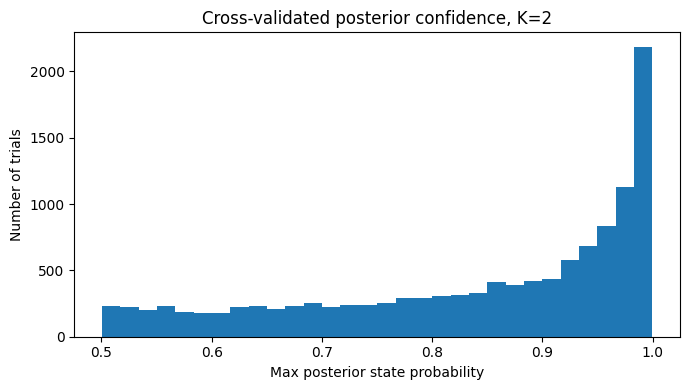

In [35]:
decoded_df, state_weight_summary = decode_early_states(
    K_TO_INTERPRET,
    RESULTS_DIR,
    best_by_K_fold,
    df_model,
    fold_mapping_session,
    obs_mat,
    obs_regressor_names,
    output,
    session,
    trans_mat,
    trans_regressor_names,
)

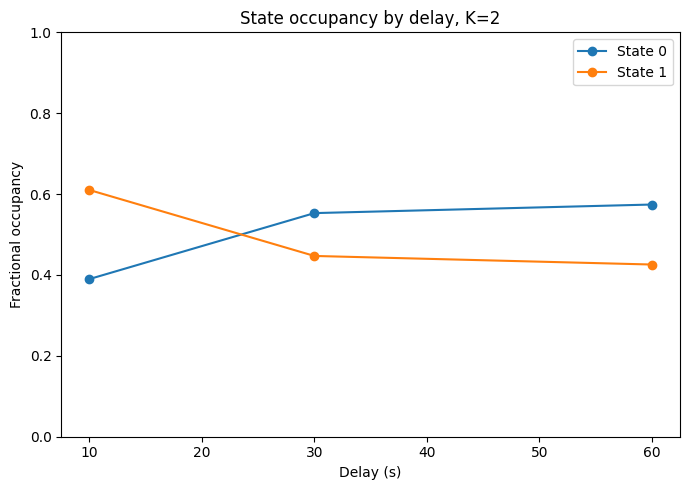

In [36]:
def label_state_from_weights(row):
    label_parts = []
    prev_choice_w = row.get("prev_choice_signed", np.nan)
    prev_reward_w = row.get("prev_reward_signed", np.nan)
    choice_outcome_w = row.get("prev_correct_side_signed", np.nan)
    bias_w = row.get("obs_bias", np.nan)
    if row["decoded_state"] == 0:
        label_parts.append("stronger rule-following-like")
    else:
        label_parts.append("weaker rule-following / more exploratory")
    if pd.notna(prev_choice_w) and abs(prev_choice_w) >= 0.2:
        label_parts.append("choice-history-influenced")
    if pd.notna(prev_reward_w) and abs(prev_reward_w) >= 0.2:
        label_parts.append("reward-history-influenced")
    if pd.notna(choice_outcome_w) and abs(choice_outcome_w) >= 0.2:
        label_parts.append("outcome-dependent-choice-history")
    if pd.notna(bias_w):
        if bias_w >= 0.2:
            label_parts.append("right-biased")
        elif bias_w <= -0.2:
            label_parts.append("left-biased")
        else:
            label_parts.append("low side-bias")
    return " + ".join(label_parts)


state_summary = summarize_early_states(K_TO_INTERPRET, RESULTS_DIR, decoded_df, state_weight_summary)

/tmp/ipykernel_985/493055258.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=[f"State {st}" for st in states])


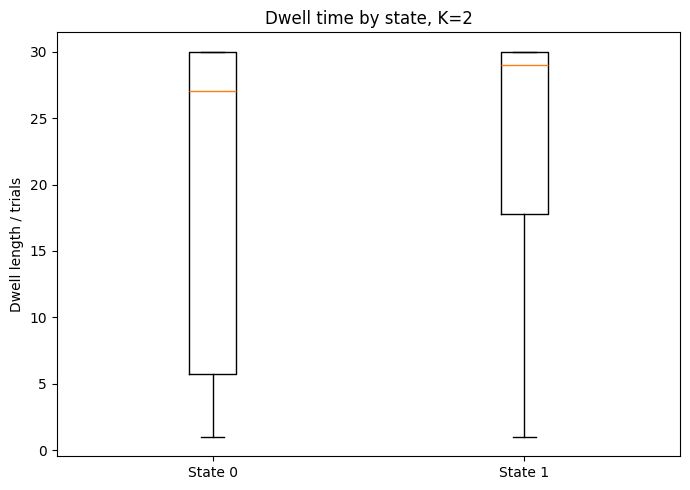

In [37]:
switch_summary, dwell_summary = summarize_early_switches(K_TO_INTERPRET, RESULTS_DIR, decoded_df)

#### 4. No-delay model

In [38]:
import os, re, json, math, copy, warnings, sys

if "IN_COLAB" not in globals():
    IN_COLAB = "google.colab" in sys.modules
PROJECT_DIR = OUTPUT_ROOT / "01_no_delay"
DATA_DIR = PROJECT_DIR
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CLEAN_CSV_PATH = INPUT_DIR / "trials_no_delay.csv"
CSV_CANDIDATES = [CLEAN_CSV_PATH]
CSV_FILENAME = CLEAN_CSV_PATH.name
RANDOM_SEED = 0
MODEL_INPUT_POLICY = "no_delay"
USE_DELAY_AS_MODEL_INPUT = False
USE_TEMPORAL_BASES_AS_MODEL_INPUT = False
CV_SCHEME = "balanced_mouse_delay_3fold_if_delay_available"
N_FOLDS = 3
TAU = 4.0
K_LIST = [2, 3]
QUICK_RUN = True
if QUICK_RUN:
    N_INITS = 3
    N_EM_ITERS = 100
else:
    N_INITS = 10
    N_EM_ITERS = 300
PRIOR_SIGMA = 100.0
TRANSITION_ALPHA = 1.0
INIT_NOISE_SCALE = 0.15
MIN_DELTA_LL_PER_TRIAL_FOR_MOUSE_SUBGROUP = 0.005

In [39]:
from IPython.display import display

df_long = pd.read_csv(CLEAN_CSV_PATH)
if "delay_s" not in df_long.columns and "delay_s_posthoc_only" in df_long.columns:
    df_long["delay_s"] = df_long["delay_s_posthoc_only"]
if "session_date" in df_long.columns:
    df_long["session_date"] = pd.to_datetime(df_long["session_date"], errors="coerce")
elif "session_date_raw" in df_long.columns:
    df_long["session_date"] = pd.to_datetime(
        df_long["session_date_raw"], unit="D", origin="1899-12-30", errors="coerce"
    )
else:
    df_long["session_date"] = pd.NaT
numeric_cols = [
    "testing_num",
    "delay_from_label",
    "session_index",
    "trial_in_session",
    "delay_s",
    "delay_s_posthoc_only",
    "correct_cumulative_original",
    "choice_right",
    "sample_right",
    "correct_side_right",
    "trial_correct",
    "correct",
]
for col in numeric_cols:
    if col in df_long.columns:
        df_long[col] = pd.to_numeric(df_long[col], errors="coerce")
for col in ["sample_side", "choice"]:
    if col in df_long.columns:
        df_long[col] = df_long[col].astype(str).str.lower().str.strip()
required_cols = ["mouse_id", "session_id", "trial_in_session", "sample_side", "choice"]
missing = [c for c in required_cols if c not in df_long.columns]
if missing:
    raise ValueError(f"Missing required columns in clean CSV: {missing}")
standardized_csv_path = RESULTS_DIR / "working_memory_loaded_standardized_copy.csv"
df_long.to_csv(standardized_csv_path, index=False)

#### Variables

In [40]:
df_model = df_long.copy()
for col in ["sample_side", "choice"]:
    df_model[col] = df_model[col].astype(str).str.lower().str.strip()
valid_sides = {"left", "right"}
bad_sample = df_model.loc[~df_model["sample_side"].isin(valid_sides)]
bad_choice = df_model.loc[~df_model["choice"].isin(valid_sides)]
if len(bad_sample) > 0:
    raise ValueError("Some sample/order values are not left/right.")
if len(bad_choice) > 0:
    raise ValueError("Some choice values are not left/right.")
sort_cols = [
    c
    for c in ["mouse_id", "session_date", "testing_num", "session_index", "trial_in_session"]
    if c in df_model.columns
]
df_model = df_model.sort_values(sort_cols).reset_index(drop=True)
validate_source_trial_columns(df_model)
for rule_col in ["correct_side_right", "trial_correct"]:
    if rule_col not in df_model.columns:
        raise ValueError(f"Missing original task-rule column: {rule_col}")
original_correct_side_right = pd.to_numeric(df_model["correct_side_right"], errors="raise").to_numpy()
original_trial_correct = pd.to_numeric(df_model["trial_correct"], errors="raise").to_numpy()
assert np.isin(original_correct_side_right, [0, 1]).all(), "Original correct_side_right must be binary."
assert np.isin(original_trial_correct, [0, 1]).all(), "Original trial_correct must be binary."
df_model["choice_right"] = (df_model["choice"] == "right").astype(int)
df_model["sample_right"] = (df_model["sample_side"] == "right").astype(int)
df_model["choice_signed"] = df_model["choice_right"] * 2 - 1
df_model["sample_signed"] = df_model["sample_right"] * 2 - 1
df_model["correct_side_signed"] = -df_model["sample_signed"]
df_model["correct_side_right"] = (df_model["correct_side_signed"] == 1).astype(int)
df_model["trial_correct"] = (df_model["choice_signed"] == df_model["correct_side_signed"]).astype(int)
df_model["correct"] = df_model["trial_correct"]
df_model["reward_signed"] = df_model["trial_correct"] * 2 - 1
assert np.array_equal(
    df_model["correct_side_right"].to_numpy(), original_correct_side_right
), "Derived non-match rule disagrees with original correct_side_right."
assert np.array_equal(
    df_model["trial_correct"].to_numpy(), original_trial_correct
), "Derived non-match rule disagrees with original trial_correct."
df_model["derived_correct_cumulative"] = df_model.groupby("session_id")["trial_correct"].cumsum()
cumulative_mismatch = get_recorded_cumulative_mismatch(df_model, RESULTS_DIR)
assert not cumulative_mismatch.any(), (
    f"Task-rule validation failed: {int(cumulative_mismatch.sum())} rows disagree with "
    "recorded cumulative correctness. Review task_rule_cumulative_mismatches.csv "
    "against source records before refitting. No discrepancies are waived."
)
summary_group = "delay_s" if "delay_s" in df_model.columns else "mouse_id"
summary_by_group = (
    df_model.groupby(summary_group)
    .agg(
        n_trials=("trial_correct", "size"),
        accuracy=("trial_correct", "mean"),
        p_right_choice=("choice_right", "mean"),
        p_right_correct_side=("correct_side_right", "mean"),
    )
    .reset_index()
)

#### Regressors

In [41]:
df_model = add_prev_within_session(df_model, "choice_signed", "prev_choice_signed")
df_model = add_prev_within_session(df_model, "correct_side_signed", "prev_correct_side_signed")
df_model = add_prev_within_session(df_model, "reward_signed", "prev_reward_signed")
df_model = exponential_filter_by_session(df_model, "prev_choice_signed", "filt_prev_choice", tau=TAU)
df_model = exponential_filter_by_session(
    df_model, "prev_correct_side_signed", "filt_prev_correct_side", tau=TAU
)
df_model = exponential_filter_by_session(df_model, "prev_reward_signed", "filt_prev_reward", tau=TAU)
if "delay_s" in df_model.columns:
    df_model["delay_z_posthoc_only"] = zscore(df_model["delay_s"])
assert np.allclose(
    df_model["prev_correct_side_signed"],
    df_model["prev_choice_signed"] * df_model["prev_reward_signed"],
), "prev_correct_side_signed must equal prev_choice_signed * prev_reward_signed."
obs_regressor_names = ["correct_side_signed", "prev_choice_signed", "prev_reward_signed", "prev_correct_side_signed", "obs_bias"]
df_model["obs_bias"] = 1.0
trans_regressor_names = ["filt_prev_choice", "filt_prev_correct_side", "filt_prev_reward", "trans_bias"]
df_model["trans_bias"] = 1.0
for forbidden in [
    "delay_s",
    "delay_z",
    "delay_z_posthoc_only",
    "correct_side_x_delay_z",
    "trial_correct",
    "correct",
]:
    assert forbidden not in obs_regressor_names, f"Forbidden observation regressor found: {forbidden}"
    assert forbidden not in trans_regressor_names, f"Forbidden transition regressor found: {forbidden}"
obs_mat = df_model[obs_regressor_names].to_numpy(dtype=float)
trans_mat = df_model[trans_regressor_names].to_numpy(dtype=float)
output = df_model["choice_right"].to_numpy(dtype=int).reshape(-1, 1)
session = df_model["session_id"].astype(str).to_numpy()
assert obs_mat.shape[0] == trans_mat.shape[0] == output.shape[0] == session.shape[0]
assert set(np.unique(output[:, 0])).issubset({0, 1})
assert np.isfinite(obs_mat).all()
assert np.isfinite(trans_mat).all()
manifest = pd.DataFrame(
    {
        "matrix": ["observation"] * len(obs_regressor_names) + ["transition"] * len(trans_regressor_names),
        "regressor": obs_regressor_names + trans_regressor_names,
    }
)
manifest_path = RESULTS_DIR / "regressors_no_delay.csv"
manifest.to_csv(manifest_path, index=False)

#### Folds

In [42]:
N_FOLDS = 3
rng = np.random.default_rng(RANDOM_SEED)
df_model = df_model.drop(columns=["fold", "fold_x", "fold_y"], errors="ignore")
session_info = make_session_info_for_folds(df_model)
if session_info["session_id"].duplicated().any():
    dup = session_info.loc[session_info["session_id"].duplicated(), "session_id"].head().tolist()
    raise ValueError(f"Session IDs are not unique in session_info. Examples: {dup}")
fold_records = []
if CV_SCHEME.startswith("balanced_mouse_delay") and "delay_s" in session_info.columns:
    group_cols = ["mouse_id", "delay_s"]
else:
    group_cols = ["mouse_id"]
for group_key, sub in session_info.groupby(group_cols, sort=False):
    sess = sub["session_id"].to_numpy().astype(str).copy()
    rng.shuffle(sess)
    if len(sess) < N_FOLDS:
        warnings.warn(
            f"Group {group_key} has only {len(sess)} sessions for {N_FOLDS} folds. Folds may be slightly imbalanced for this group."
        )
    for i, sid in enumerate(sess):
        fold_records.append({"session_id": sid, "fold": int(i % N_FOLDS)})
fold_df = pd.DataFrame(fold_records)
fold_df["fold"] = fold_df["fold"].astype(int)
df_model = df_model.merge(fold_df, on="session_id", how="left")
if df_model["fold"].isna().any():
    missing_sessions = df_model.loc[df_model["fold"].isna(), "session_id"].unique()[:10]
    raise ValueError(f"Some trials did not receive a fold assignment. Examples: {missing_sessions}")
df_model["fold"] = df_model["fold"].astype(int)
fold_mapping_session = fold_df[["session_id", "fold"]].to_numpy(dtype=object)
fold_session_summary = (
    df_model[["mouse_id", "session_id", "fold"]]
    .drop_duplicates()
    .groupby("fold")
    .agg(n_mice=("mouse_id", "nunique"), n_sessions=("session_id", "nunique"))
    .reset_index()
)
fold_trial_summary = (
    df_model.groupby("fold")
    .agg(
        n_mice=("mouse_id", "nunique"), n_sessions=("session_id", "nunique"), n_trials=("session_id", "size")
    )
    .reset_index()
)
if "delay_s" in session_info.columns:
    fold_delay_summary = (
        session_info.merge(fold_df, on="session_id", how="left")
        .groupby(["fold", "delay_s"])
        .size()
        .unstack(fill_value=0)
    )
for fold in range(N_FOLDS):
    test_sessions_n = fold_df.loc[fold_df["fold"] == fold, "session_id"].nunique()
    train_sessions_n = fold_df.loc[fold_df["fold"] != fold, "session_id"].nunique()
    test_trials_n = int((df_model["fold"] == fold).sum())
    train_trials_n = int((df_model["fold"] != fold).sum())
np.savez(DATA_DIR / "trial_arrays_3fold.npz", obs_mat, trans_mat, output, session)
np.savez(DATA_DIR / "session_folds_3fold.npz", fold_mapping_session)
np.savez(
    DATA_DIR / "regressors_3fold.npz",
    obs_regressor_names=np.array(obs_regressor_names),
    trans_regressor_names=np.array(trans_regressor_names),
)
df_model.to_csv(DATA_DIR / "trial_metadata_3fold.csv", index=False)
fold_df.to_csv(RESULTS_DIR / "fold_mapping_session_3fold.csv", index=False)
fold_df.to_csv(RESULTS_DIR / "fold_mapping_session.csv", index=False)

#### Sequences

In [43]:
_ = check_session_segmentation()

In [44]:
assert N_FOLDS == 3, f"Expected N_FOLDS=3, got {N_FOLDS}"
for forbidden in [
    "delay_s",
    "delay_z",
    "delay_z_posthoc_only",
    "correct_side_x_delay_z",
    "trial_correct",
    "correct",
]:
    assert forbidden not in obs_regressor_names, f"Forbidden observation regressor found: {forbidden}"
    assert forbidden not in trans_regressor_names, f"Forbidden transition regressor found: {forbidden}"
fold_counts = pd.Series(fold_mapping_session[:, 1].astype(int)).value_counts().sort_index()
if len(fold_counts) != 3:
    raise ValueError("Fold mapping does not contain exactly 3 folds.")

#### K=1

In [45]:
def eval_logistic_glm(w, X, y):
    logits = X @ w
    p = np.clip(sigmoid(logits), 1e-09, 1 - 1e-09)
    ll_per_trial = y * np.log(p) + (1 - y) * np.log(1 - p)
    ll = np.sum(ll_per_trial)
    acc = np.mean((p >= 0.5).astype(int) == y)
    return (ll, acc, ll_per_trial, p)


X_obs = obs_mat.copy()
y = output[:, 0].astype(int)
glm_summary_rows = []
glm_session_ll_rows = []
for fold in range(N_FOLDS):
    train_sessions = fold_mapping_session[fold_mapping_session[:, 1].astype(int) != fold, 0].astype(str)
    test_sessions = fold_mapping_session[fold_mapping_session[:, 1].astype(int) == fold, 0].astype(str)
    train_idx = np.isin(session, train_sessions)
    test_idx = np.isin(session, test_sessions)
    X_train, y_train = (X_obs[train_idx], y[train_idx])
    X_test, y_test = (X_obs[test_idx], y[test_idx])
    w_hat, train_ll, opt = fit_logistic_glm(X_train, y_train, prior_sigma=PRIOR_SIGMA)
    test_ll, test_acc, ll_per_trial, p_test = eval_logistic_glm(w_hat, X_test, y_test)
    p_right_train = np.clip(np.mean(y_train), 1e-09, 1 - 1e-09)
    baseline_test_ll = np.sum(y_test * np.log(p_right_train) + (1 - y_test) * np.log(1 - p_right_train))
    bits_over_baseline = (test_ll - baseline_test_ll) / (len(y_test) * np.log(2))
    fold_dir = RESULTS_DIR / "Model" / "glm_#state=1" / f"fld_num={fold}"
    fold_dir.mkdir(parents=True, exist_ok=True)
    glm_weights_for_hmm = w_hat.reshape(1, 1, -1)
    np.savez(fold_dir / "important_params_iter_0.npz", train_ll, glm_weights_for_hmm)
    test_meta = df_model.loc[test_idx, ["mouse_id", "session_id"]].copy().reset_index(drop=True)
    test_meta["trial_ll"] = ll_per_trial
    test_meta["y_choice_right"] = y_test
    test_meta["p_choice_right"] = p_test
    sess_ll = test_meta.groupby(["mouse_id", "session_id"], as_index=False).agg(
        test_ll=("trial_ll", "sum"),
        n_test_trials=("trial_ll", "size"),
        mean_p_choice_right=("p_choice_right", "mean"),
        choice_right_rate=("y_choice_right", "mean"),
    )
    sess_ll["K"] = 1
    sess_ll["fold"] = fold
    sess_ll["iter"] = 0
    sess_ll["selected_by"] = "glm_1state"
    sess_ll["test_ll_per_trial"] = sess_ll["test_ll"] / sess_ll["n_test_trials"]
    glm_session_ll_rows.append(sess_ll)
    glm_summary_rows.append(
        {
            "K": 1,
            "fold": fold,
            "n_train_trials": int(train_idx.sum()),
            "n_test_trials": int(test_idx.sum()),
            "train_ll": float(train_ll),
            "test_ll": float(test_ll),
            "test_ll_per_trial": float(test_ll / len(y_test)),
            "test_accuracy": float(test_acc),
            "baseline_test_ll": float(baseline_test_ll),
            "bits_per_trial_over_baseline": float(bits_over_baseline),
            **{f"w_{name}": float(val) for name, val in zip(obs_regressor_names, w_hat)},
        }
    )
glm_summary = pd.DataFrame(glm_summary_rows)
glm_summary_path = RESULTS_DIR / "glm_1state_cv_summary.csv"
glm_summary.to_csv(glm_summary_path, index=False)
glm_session_ll = pd.concat(glm_session_ll_rows, ignore_index=True)
glm_session_ll_path = RESULTS_DIR / "glm_1state_session_ll.csv"
glm_session_ll.to_csv(glm_session_ll_path, index=False)

#### GLM-HMM

In [46]:
def fit_one_glmhmm(K, fold, iter_id, num_iters=N_EM_ITERS):
    train_sessions = fold_mapping_session[fold_mapping_session[:, 1].astype(int) != fold, 0].astype(str)
    test_sessions = fold_mapping_session[fold_mapping_session[:, 1].astype(int) == fold, 0].astype(str)
    train_idx = np.isin(session, train_sessions)
    test_idx = np.isin(session, test_sessions)
    obs_train = obs_mat[train_idx]
    trans_train = trans_mat[train_idx]
    y_train = output[train_idx]
    session_train = session[train_idx]
    obs_test = obs_mat[test_idx]
    trans_test = trans_mat[test_idx]
    y_test = output[test_idx]
    session_test = session[test_idx]
    inputs_train, inputs_trans_train, datas_train, masks_train, session_ids_train = segment_by_session(
        obs_train, trans_train, y_train, session_train
    )
    inputs_test, inputs_trans_test, datas_test, masks_test, session_ids_test = segment_by_session(
        obs_test, trans_test, y_test, session_test
    )
    M_obs = obs_mat.shape[1]
    M_trans = trans_mat.shape[1]
    glm_init_path = RESULTS_DIR / "Model" / "glm_#state=1" / f"fld_num={fold}" / "important_params_iter_0.npz"
    glm_container = np.load(glm_init_path, allow_pickle=True)
    glm_weights = glm_container["arr_1"]
    np.random.seed(RANDOM_SEED + 10000 * K + 100 * fold + iter_id)
    model = make_hmm(K, M_obs, M_trans, C=2, D=1, prior_sigma=PRIOR_SIGMA, transition_alpha=TRANSITION_ALPHA)
    model = initialize_hmm_from_glm(model, glm_weights, K=K, seed=iter_id, noise_scale=INIT_NOISE_SCALE)
    print(
        f"Fitting K={K}, fold={fold}, init={iter_id}, train sessions={len(session_ids_train)}, test sessions={len(session_ids_test)}"
    )
    initial_train_ll = hmm_log_probability(
        model, datas_train, inputs_train, inputs_trans_train, masks_train
    )
    lls = model.fit(
        datas_train,
        transition_input=inputs_trans_train,
        observation_input=inputs_train,
        masks=masks_train,
        method="em",
        num_iters=num_iters,
        initialize=False,
        tolerance=0.0001,
    )
    # EM history contains a regularized, lagged objective; score final parameters directly.
    final_train_ll = hmm_log_probability(
        model, datas_train, inputs_train, inputs_trans_train, masks_train
    )
    if not np.isfinite(final_train_ll):
        raise ValueError("Non-finite final training likelihood.")
    test_ll = hmm_log_probability_strict(model, datas_test, inputs_test, inputs_trans_test, masks_test)
    test_ll = float(np.asarray(test_ll))
    test_n = int(y_test.shape[0])
    train_n = int(y_train.shape[0])
    p_right_train = np.clip(np.mean(y_train[:, 0]), 1e-09, 1 - 1e-09)
    baseline_test_ll = np.sum(
        y_test[:, 0] * np.log(p_right_train) + (1 - y_test[:, 0]) * np.log(1 - p_right_train)
    )
    bits_over_baseline = (test_ll - baseline_test_ll) / (test_n * np.log(2))
    save_dir = RESULTS_DIR / "Model" / f"glmhmm_#state={K}" / f"fld_num={fold}" / f"iter_{iter_id}"
    save_dir.mkdir(parents=True, exist_ok=True)
    raw_param_path = save_dir / f"glm_hmm_raw_parameters_itr_{iter_id}.pkl"
    session_mouse_map = (
        df_model[["session_id", "mouse_id"]]
        .drop_duplicates()
        .set_index("session_id")["mouse_id"]
        .astype(str)
        .to_dict()
    )
    session_ll_rows = []
    for sid, data_s, obs_s, trans_s, mask_s in zip(
        session_ids_test, datas_test, inputs_test, inputs_trans_test, masks_test
    ):
        ll_s = hmm_log_probability_strict(model, [data_s], [obs_s], [trans_s], [mask_s])
        n_s = int(np.asarray(data_s).shape[0])
        session_ll_rows.append(
            {
                "K": int(K),
                "fold": int(fold),
                "iter": int(iter_id),
                "mouse_id": session_mouse_map.get(str(sid), "unknown"),
                "session_id": str(sid),
                "n_test_trials": n_s,
                "test_ll": float(ll_s),
                "test_ll_per_trial": float(ll_s / n_s),
            }
        )
    session_ll_df = pd.DataFrame(session_ll_rows)
    assert np.isclose(session_ll_df["test_ll"].sum(), test_ll, rtol=1e-10, atol=1e-7), (
        "Session test likelihoods must sum to the fold test likelihood."
    )
    session_ll_path = save_dir / f"session_test_ll_K{K}_fold{fold}_iter{iter_id}.csv"
    session_ll_df.to_csv(session_ll_path, index=False)
    save_payload = {
        "K": K,
        "fold": fold,
        "iter_id": iter_id,
        "model_params": model.params,
        "init_state_distn_params": model.init_state_distn.params,
        "transition_params": model.transitions.params,
        "observation_params": model.observations.params,
        "lls": np.asarray(lls, dtype=float),  # Regularized EM trace.
        "final_train_ll": float(final_train_ll),
        "obs_regressor_names": list(obs_regressor_names),
        "trans_regressor_names": list(trans_regressor_names),
        "train_session_ids": list(session_ids_train),
        "test_session_ids": list(session_ids_test),
        "n_train_trials": train_n,
        "n_test_trials": test_n,
        "test_ll": test_ll,
        "baseline_test_ll": float(baseline_test_ll),
        "bits_per_trial_over_baseline": float(bits_over_baseline),
        "session_ll_path": str(session_ll_path),
        "model_input_policy": MODEL_INPUT_POLICY,
    }
    with open(raw_param_path, "wb") as f:
        pickle.dump(save_payload, f)
    lls_path = save_dir / f"glm_hmm_lls_itr_{iter_id}.npy"
    np.save(lls_path, np.asarray(lls, dtype=float))
    row = {
        "K": K,
        "fold": fold,
        "iter": iter_id,
        "n_train_trials": train_n,
        "n_test_trials": test_n,
        "n_train_sessions": len(session_ids_train),
        "n_test_sessions": len(session_ids_test),
        "initial_train_ll": float(initial_train_ll),
        "final_train_ll": float(final_train_ll),
        "train_ll_improvement": float(final_train_ll - initial_train_ll),
        "test_ll": float(test_ll),
        "test_ll_per_trial": float(test_ll / test_n),
        "baseline_test_ll": float(baseline_test_ll),
        "bits_per_trial_over_baseline": float(bits_over_baseline),
        "raw_param_path": str(raw_param_path),
        "lls_path": str(lls_path),
        "session_ll_path": str(session_ll_path),
    }
    return row

In [47]:
hmm_log_probability = hmm_log_probability_strict

#### Fitting

In [48]:
all_hmm_rows = []
for K in K_LIST:
    for fold in range(N_FOLDS):
        for iter_id in range(N_INITS):
            row = fit_one_glmhmm(K=K, fold=fold, iter_id=iter_id, num_iters=N_EM_ITERS)
            all_hmm_rows.append(row)
            running = pd.DataFrame(all_hmm_rows)
            running_path = RESULTS_DIR / "glmhmm_all_fits_running_summary.csv"
            running.to_csv(running_path, index=False)
hmm_all = pd.DataFrame(all_hmm_rows)
hmm_all_path = RESULTS_DIR / "glmhmm_all_fits_summary.csv"
hmm_all.to_csv(hmm_all_path, index=False)

Fitting K=2, fold=0, init=0, train sessions=270, test sessions=135


  0%|          | 0/100 [00:00<?, ?it/s]

Fitting K=2, fold=0, init=1, train sessions=270, test sessions=135


  0%|          | 0/100 [00:00<?, ?it/s]

Fitting K=2, fold=0, init=2, train sessions=270, test sessions=135


...

  0%|          | 0/100 [00:00<?, ?it/s]

Fitting K=3, fold=2, init=1, train sessions=270, test sessions=135


  0%|          | 0/100 [00:00<?, ?it/s]

Fitting K=3, fold=2, init=2, train sessions=270, test sessions=135


  0%|          | 0/100 [00:00<?, ?it/s]

#### Model comparison

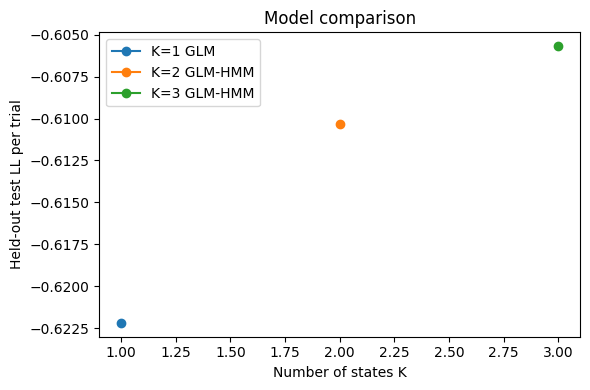

,K,mean_test_ll_per_trial,mean_delta_bits_per_trial_vs_glm,min_delta_bits_per_trial_vs_glm,max_delta_bits_per_trial_vs_glm,mean_train_ll_improvement,selected_by_mean_test_ll
0,1,-0.622182,0.000000,0.000000,0.000000,NaN,False
1,2,-0.610345,0.017078,0.015162,0.018669,147.116613,False
2,3,-0.605683,0.023803,0.020185,0.026634,186.995437,True


In [49]:
glm_summary = pd.read_csv(RESULTS_DIR / "glm_1state_cv_summary.csv")
hmm_all = pd.read_csv(RESULTS_DIR / "glmhmm_all_fits_summary.csv")
hmm_best = (
    hmm_all.sort_values(["K", "fold", "final_train_ll"], ascending=[True, True, False])
    .groupby(["K", "fold"], as_index=False)
    .first()
)
hmm_best["selected_by"] = "highest_final_train_ll"
hmm_best_path = RESULTS_DIR / "glmhmm_best_by_K_fold.csv"
hmm_best.to_csv(hmm_best_path, index=False)
glm_for_merge = glm_summary[["fold", "test_ll", "test_ll_per_trial", "test_accuracy"]].rename(
    columns={
        "test_ll": "glm_test_ll",
        "test_ll_per_trial": "glm_test_ll_per_trial",
        "test_accuracy": "glm_test_accuracy",
    }
)
comparison = hmm_best.merge(glm_for_merge, on="fold", how="left")
comparison["delta_ll_vs_glm"] = comparison["test_ll"] - comparison["glm_test_ll"]
comparison["delta_bits_per_trial_vs_glm"] = comparison["delta_ll_vs_glm"] / (
    comparison["n_test_trials"] * np.log(2)
)
comparison_path = RESULTS_DIR / "model_comparison_vs_1state_GLM.csv"
comparison.to_csv(comparison_path, index=False)
model_selection_summary = (
    comparison.groupby("K")
    .agg(
        mean_test_ll_per_trial=("test_ll_per_trial", "mean"),
        mean_delta_bits_per_trial_vs_glm=("delta_bits_per_trial_vs_glm", "mean"),
        min_delta_bits_per_trial_vs_glm=("delta_bits_per_trial_vs_glm", "min"),
        max_delta_bits_per_trial_vs_glm=("delta_bits_per_trial_vs_glm", "max"),
        mean_train_ll_improvement=("train_ll_improvement", "mean"),
    )
    .reset_index()
)
k1_row = pd.DataFrame(
    {
        "K": [1],
        "mean_test_ll_per_trial": [glm_summary["test_ll_per_trial"].mean()],
        "mean_delta_bits_per_trial_vs_glm": [0.0],
        "min_delta_bits_per_trial_vs_glm": [0.0],
        "max_delta_bits_per_trial_vs_glm": [0.0],
        "mean_train_ll_improvement": [np.nan],
    }
)
model_selection_summary_with_k1 = pd.concat([k1_row, model_selection_summary], ignore_index=True)
best_K_by_test = int(
    model_selection_summary_with_k1.sort_values("mean_test_ll_per_trial", ascending=False).iloc[0]["K"]
)
model_selection_summary_with_k1["selected_by_mean_test_ll"] = (
    model_selection_summary_with_k1["K"] == best_K_by_test
)
model_selection_path = RESULTS_DIR / "model_selection_summary_with_K1.csv"
model_selection_summary_with_k1.to_csv(model_selection_path, index=False)
plt.figure(figsize=(6, 4))
plt.plot([1], [glm_summary["test_ll_per_trial"].mean()], marker="o", label="K=1 GLM")
for K, sub in comparison.groupby("K"):
    plt.plot([K], [sub["test_ll_per_trial"].mean()], marker="o", label=f"K={K} GLM-HMM")
plt.xlabel("Number of states K")
plt.ylabel("Held-out test LL per trial")
plt.title("Model comparison")
plt.legend()
plt.tight_layout()
fig_path = RESULTS_DIR / "model_comparison_no_delay.png"
plt.savefig(fig_path, dpi=300)
plt.show()

model_selection_summary_with_k1

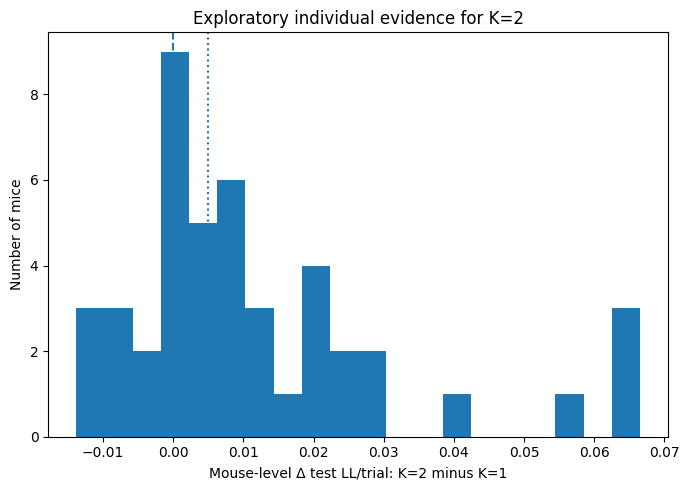

In [50]:
glm_session_ll_path = RESULTS_DIR / "glm_1state_session_ll.csv"
if not glm_session_ll_path.exists():
    raise FileNotFoundError("Run the K=1 cell first to create glm_1state_session_ll.csv")
glm_session_ll = pd.read_csv(glm_session_ll_path)
glm_session_ll["model_label"] = "K1_GLM"
hmm_best = pd.read_csv(RESULTS_DIR / "glmhmm_best_by_K_fold.csv")
hmm_session_frames = []
for _, r in hmm_best.iterrows():
    path = Path(r["session_ll_path"])
    if not path.exists():
        warnings.warn(f"Missing session-level LL file for K={r['K']} fold={r['fold']}: {path}")
        continue
    tmp = pd.read_csv(path)
    tmp["selected_by"] = r.get("selected_by", "highest_final_train_ll")
    tmp["raw_param_path"] = r.get("raw_param_path", "")
    tmp["model_label"] = "K" + tmp["K"].astype(int).astype(str) + "_GLMHMM"
    hmm_session_frames.append(tmp)
if len(hmm_session_frames) == 0:
    raise RuntimeError("No HMM session-level likelihood files found. Run the model-fitting cells first.")
hmm_session_ll = pd.concat(hmm_session_frames, ignore_index=True)
session_model_ll = pd.concat(
    [
        glm_session_ll[
            [
                "K",
                "fold",
                "iter",
                "mouse_id",
                "session_id",
                "n_test_trials",
                "test_ll",
                "test_ll_per_trial",
                "model_label",
            ]
        ],
        hmm_session_ll[
            [
                "K",
                "fold",
                "iter",
                "mouse_id",
                "session_id",
                "n_test_trials",
                "test_ll",
                "test_ll_per_trial",
                "model_label",
            ]
        ],
    ],
    ignore_index=True,
)
session_model_ll_path = RESULTS_DIR / "session_level_model_ll_selected_models.csv"
session_model_ll.to_csv(session_model_ll_path, index=False)
mouse_model_ll = session_model_ll.groupby(["mouse_id", "K"], as_index=False).agg(
    total_test_ll=("test_ll", "sum"),
    n_test_trials=("n_test_trials", "sum"),
    n_test_sessions=("session_id", "nunique"),
)
mouse_model_ll["test_ll_per_trial"] = mouse_model_ll["total_test_ll"] / mouse_model_ll["n_test_trials"]
mouse_pivot = mouse_model_ll.pivot(index="mouse_id", columns="K", values="test_ll_per_trial")
mouse_pivot.columns = [f"K{int(c)}_test_ll_per_trial" for c in mouse_pivot.columns]
mouse_pivot = mouse_pivot.reset_index()
for k in [2, 3]:
    if f"K{k}_test_ll_per_trial" in mouse_pivot.columns and "K1_test_ll_per_trial" in mouse_pivot.columns:
        mouse_pivot[f"delta_K{k}_minus_K1_ll_per_trial"] = (
            mouse_pivot[f"K{k}_test_ll_per_trial"] - mouse_pivot["K1_test_ll_per_trial"]
        )
if "K3_test_ll_per_trial" in mouse_pivot.columns and "K2_test_ll_per_trial" in mouse_pivot.columns:
    mouse_pivot["delta_K3_minus_K2_ll_per_trial"] = (
        mouse_pivot["K3_test_ll_per_trial"] - mouse_pivot["K2_test_ll_per_trial"]
    )
ll_cols = [c for c in mouse_pivot.columns if c.endswith("_test_ll_per_trial")]


def choose_mouse_label(row):
    available = {int(c[1]): row[c] for c in ll_cols if pd.notna(row[c])}
    if len(available) == 0:
        return "missing"
    best_k = max(available, key=available.get)
    if best_k == 1:
        return "K1-like / stable single-policy"
    delta = row.get(f"delta_K{best_k}_minus_K1_ll_per_trial", np.nan)
    if pd.isna(delta) or delta < MIN_DELTA_LL_PER_TRIAL_FOR_MOUSE_SUBGROUP:
        return "K1-like / complex-model gain too small"
    if best_k == 2:
        return "K2-preferring exploratory subgroup"
    if best_k == 3:
        return "K3-preferring exploratory; check occupancy/stability"
    return "unclassified"


mouse_pivot["best_K_by_mouse_test_ll"] = (
    mouse_pivot[ll_cols].idxmax(axis=1).str.extract("K(\\d+)").astype(int)
)
mouse_pivot["exploratory_mouse_model_group"] = mouse_pivot.apply(choose_mouse_label, axis=1)
mouse_pref_path = RESULTS_DIR / "mouse_level_model_preference_exploratory.csv"
mouse_pivot.to_csv(mouse_pref_path, index=False)
plt.figure(figsize=(7, 5))
if "delta_K2_minus_K1_ll_per_trial" in mouse_pivot.columns:
    plt.hist(mouse_pivot["delta_K2_minus_K1_ll_per_trial"].dropna(), bins=20)
    plt.axvline(0, linestyle="--")
    plt.axvline(MIN_DELTA_LL_PER_TRIAL_FOR_MOUSE_SUBGROUP, linestyle=":")
    plt.xlabel("Mouse-level Δ test LL/trial: K=2 minus K=1")
    plt.ylabel("Number of mice")
    plt.title("Exploratory individual evidence for K=2")
    plt.tight_layout()
    fig_path = RESULTS_DIR / "mouse_delta_K2_minus_K1_hist.png"
    plt.savefig(fig_path, dpi=300)
    plt.show()

In [51]:
best_by_K_fold_path = RESULTS_DIR / "glmhmm_best_by_K_fold.csv"
if not best_by_K_fold_path.exists():
    raise FileNotFoundError(f"Could not find {best_by_K_fold_path}. Run the preceding model-comparison cells first.")
best_by_K_fold = pd.read_csv(best_by_K_fold_path)
K_TO_INTERPRET = 2
model, best_row, payload = load_best_model(K_TO_INTERPRET)
obs_w = get_observation_weight_matrix(model)
obs_weight_df = pd.DataFrame(obs_w, columns=obs_regressor_names)
obs_weight_df.insert(0, "state", np.arange(obs_weight_df.shape[0]))

#### State decoding

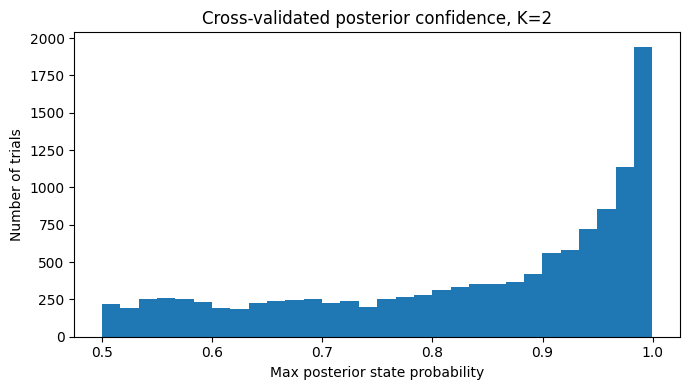

In [52]:
decoded_df, state_weight_summary = decode_early_states(
    K_TO_INTERPRET,
    RESULTS_DIR,
    best_by_K_fold,
    df_model,
    fold_mapping_session,
    obs_mat,
    obs_regressor_names,
    output,
    session,
    trans_mat,
    trans_regressor_names,
)

#### State summaries

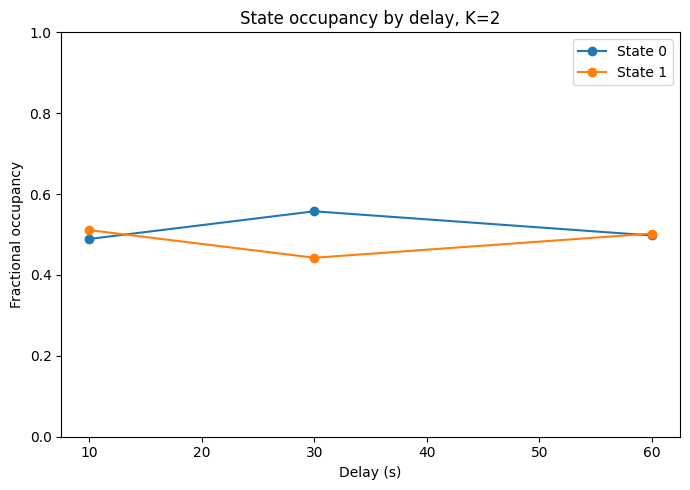

In [53]:
state_summary = summarize_early_states(K_TO_INTERPRET, RESULTS_DIR, decoded_df, state_weight_summary)

#### Switching and dwell times

/tmp/ipykernel_985/493055258.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=[f"State {st}" for st in states])


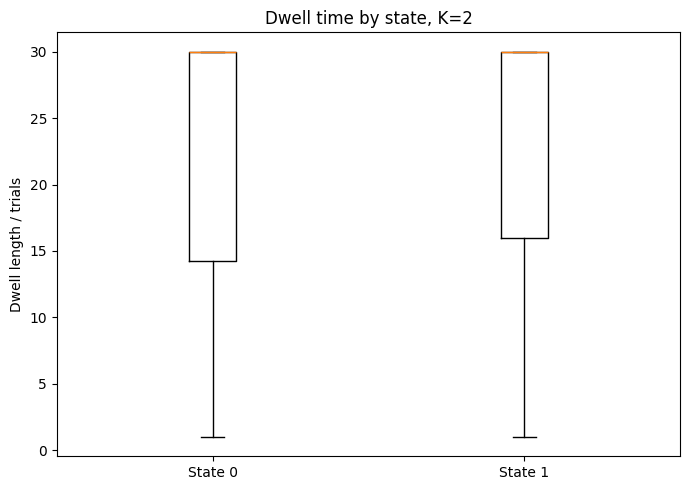

In [54]:
switch_summary, dwell_summary = summarize_early_switches(K_TO_INTERPRET, RESULTS_DIR, decoded_df)

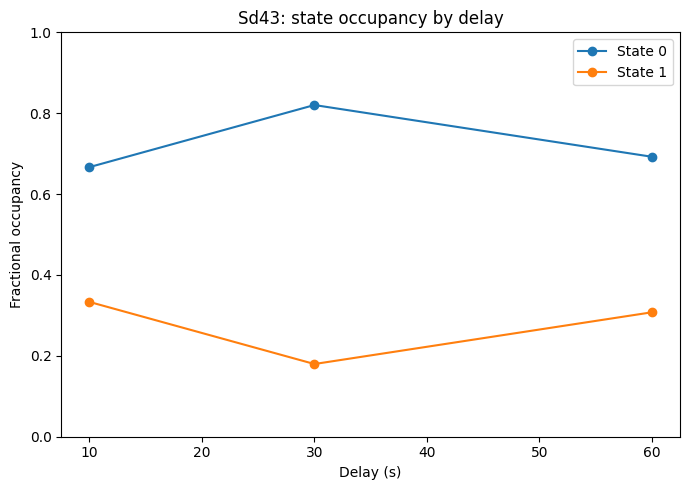

In [55]:
if "state_summary" in globals():
    if "exploratory_state_label" in state_summary.columns:
        state_label_table = state_summary[["decoded_state", "exploratory_state_label"]].copy()
    else:
        state_label_table = state_summary[["decoded_state"]].copy()
        state_label_table["exploratory_state_label"] = "exploratory state " + state_label_table[
            "decoded_state"
        ].astype(str)
else:
    state_label_table = pd.DataFrame({"decoded_state": sorted(decoded_df["decoded_state"].dropna().unique())})
    state_label_table["exploratory_state_label"] = "exploratory state " + state_label_table[
        "decoded_state"
    ].astype(int).astype(str)
MOUSE_TO_REPORT = "Sd43"
if MOUSE_TO_REPORT not in decoded_df["mouse_id"].astype(str).unique():
    MOUSE_TO_REPORT = sorted(decoded_df["mouse_id"].astype(str).unique())[0]
mouse_occ, mouse_delay_occ, estimated_n_strategies = mouse_strategy_report(
    MOUSE_TO_REPORT, decoded_df, min_occupancy=0.1, min_median_dwell=3
)

#### Mouse summaries

In [56]:
all_mouse_reports = summarize_mouse_strategies(K_TO_INTERPRET, RESULTS_DIR, decoded_df)

In [57]:
if "K_TO_INTERPRET" not in globals():
    K_TO_INTERPRET = 2
all_mouse_report_path = RESULTS_DIR / f"mouse_strategy_summary_K{K_TO_INTERPRET}.csv"
all_mouse_reports = pd.read_csv(all_mouse_report_path)

In [58]:
clean_report = all_mouse_reports.copy()
occupancy_cols = [c for c in clean_report.columns if "occupancy" in c]
for c in occupancy_cols:
    clean_report[c] = clean_report[c].fillna(0)
used_cols = [c for c in clean_report.columns if "counts_as_used" in c]
for c in used_cols:
    clean_report[c] = clean_report[c].fillna(False).astype(bool)
clean_path = RESULTS_DIR / f"mouse_strategy_summary_K{K_TO_INTERPRET}_clean.csv"
clean_report.to_csv(clean_path, index=False)

/tmp/ipykernel_985/2133353730.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  clean_report[c] = clean_report[c].fillna(False).astype(bool)


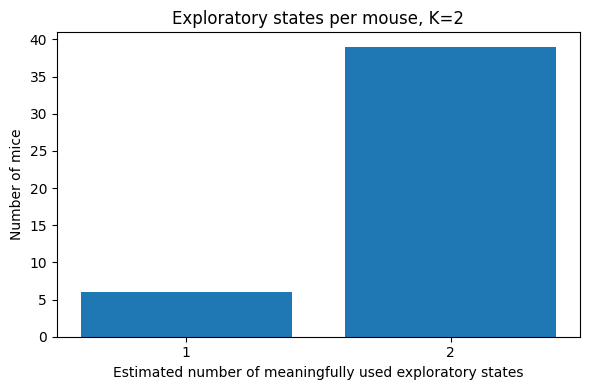

In [59]:
state_count_summary = clean_report["estimated_n_exploratory_states"].value_counts().sort_index().reset_index()
state_count_summary.columns = ["estimated_n_exploratory_states", "n_mice"]
state_count_path = RESULTS_DIR / f"estimated_n_states_per_mouse_K{K_TO_INTERPRET}.csv"
state_count_summary.to_csv(state_count_path, index=False)
plt.figure(figsize=(6, 4))
plt.bar(state_count_summary["estimated_n_exploratory_states"].astype(str), state_count_summary["n_mice"])
plt.xlabel("Estimated number of meaningfully used exploratory states")
plt.ylabel("Number of mice")
plt.title(f"Exploratory states per mouse, K={K_TO_INTERPRET}")
plt.tight_layout()
fig_path = RESULTS_DIR / f"estimated_n_states_per_mouse_K{K_TO_INTERPRET}.png"
plt.savefig(fig_path, dpi=300)
plt.show()

In [60]:
if "state_1_occupancy" not in clean_report.columns:
    clean_report["state_1_occupancy"] = 0
state1_rank = clean_report.sort_values("state_1_occupancy", ascending=False).copy()
rank_cols = [
    "mouse_id",
    "overall_accuracy",
    "estimated_n_exploratory_states",
    "state_0_occupancy",
    "state_1_occupancy",
    "state_0_accuracy",
    "state_1_accuracy",
    "state_1_occupancy_delay_10s",
    "state_1_occupancy_delay_30s",
    "state_1_occupancy_delay_60s",
]
rank_cols = [c for c in rank_cols if c in state1_rank.columns]
state1_rank_path = RESULTS_DIR / f"mice_ranked_by_state1_occupancy_K{K_TO_INTERPRET}.csv"
state1_rank.to_csv(state1_rank_path, index=False)

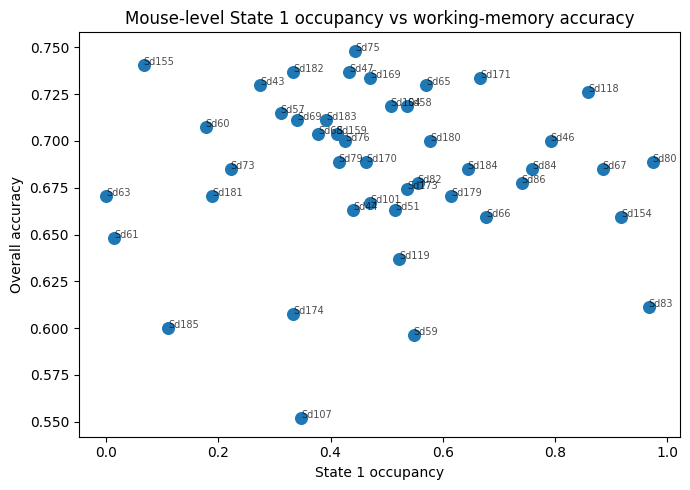

In [61]:
plt.figure(figsize=(7, 5))
plt.scatter(clean_report["state_1_occupancy"], clean_report["overall_accuracy"], s=70)
for _, row in clean_report.iterrows():
    plt.text(row["state_1_occupancy"], row["overall_accuracy"], row["mouse_id"], fontsize=7, alpha=0.7)
plt.xlabel("State 1 occupancy")
plt.ylabel("Overall accuracy")
plt.title("Mouse-level State 1 occupancy vs working-memory accuracy")
plt.tight_layout()
fig_path = RESULTS_DIR / f"state1_occupancy_vs_accuracy_K{K_TO_INTERPRET}.png"
plt.savefig(fig_path, dpi=300)
plt.show()
valid = clean_report[["state_1_occupancy", "overall_accuracy"]].dropna()
if len(valid) >= 3:
    pearson_r = valid["state_1_occupancy"].corr(valid["overall_accuracy"], method="pearson")
    spearman_rho = valid["state_1_occupancy"].corr(valid["overall_accuracy"], method="spearman")

In [62]:
strategy_feature_cols = [
    "mouse_id",
    "overall_accuracy",
    "estimated_n_exploratory_states",
    "state_0_occupancy",
    "state_1_occupancy",
    "state_0_accuracy",
    "state_1_accuracy",
    "state_0_right_choice_rate",
    "state_1_right_choice_rate",
    "state_0_median_dwell",
    "state_1_median_dwell",
    "state_0_mean_max_prob",
    "state_1_mean_max_prob",
    "state_0_occupancy_delay_10s",
    "state_0_occupancy_delay_30s",
    "state_0_occupancy_delay_60s",
    "state_1_occupancy_delay_10s",
    "state_1_occupancy_delay_30s",
    "state_1_occupancy_delay_60s",
]
strategy_feature_cols = [c for c in strategy_feature_cols if c in clean_report.columns]
strategy_features_for_blind = clean_report[strategy_feature_cols].copy()
if (
    "state_1_occupancy_delay_10s" in strategy_features_for_blind.columns
    and "state_1_occupancy_delay_60s" in strategy_features_for_blind.columns
):
    strategy_features_for_blind["state1_occupancy_60s_minus_10s"] = (
        strategy_features_for_blind["state_1_occupancy_delay_60s"]
        - strategy_features_for_blind["state_1_occupancy_delay_10s"]
    )
if (
    "state_1_accuracy" in strategy_features_for_blind.columns
    and "state_0_accuracy" in strategy_features_for_blind.columns
):
    strategy_features_for_blind["state1_minus_state0_accuracy"] = (
        strategy_features_for_blind["state_1_accuracy"] - strategy_features_for_blind["state_0_accuracy"]
    )
final_feature_path = RESULTS_DIR / f"mouse_strategy_features_K{K_TO_INTERPRET}.csv"
strategy_features_for_blind.to_csv(final_feature_path, index=False)

In [63]:
import warnings

warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    balanced_accuracy_score,
    roc_auc_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from scipy import stats
from scipy.stats import fisher_exact, chi2_contingency

BLIND_DIR = RESULTS_DIR / "blinded_strategy_analysis"
BLIND_DIR.mkdir(parents=True, exist_ok=True)
K_TO_INTERPRET = 2
FEATURE_PATH = RESULTS_DIR / f"mouse_strategy_features_K{K_TO_INTERPRET}.csv"
if not FEATURE_PATH.exists():
    possible_files = sorted(
        list(RESULTS_DIR.rglob("*mouse*strategy*features*.csv"))
        + list(RESULTS_DIR.rglob("*mouse*strategy*summary*.csv"))
        + list(RESULTS_DIR.rglob("*mouse*level*.csv"))
        + list(RESULTS_DIR.rglob(f"*K{K_TO_INTERPRET}*.csv"))
    )
    possible_files = list(dict.fromkeys(possible_files))
    if len(possible_files) == 0:
        raise FileNotFoundError(
            "Mouse-level strategy feature file has not been created yet. Run the previous state decoding / mouse strategy feature export step first."
        )
    preferred = [
        p
        for p in possible_files
        if f"K{K_TO_INTERPRET}" in p.name
        and ("mouse_strategy_features" in p.name or "strategy_features" in p.name)
    ]
    if len(preferred) > 0:
        FEATURE_PATH = preferred[0]
    else:
        FEATURE_PATH = possible_files[0]
strategy_features = pd.read_csv(FEATURE_PATH)
if "mouse_id" not in strategy_features.columns:
    raise ValueError(
        "This file does not contain 'mouse_id'. It may not be the correct mouse-level strategy feature file."
    )

#### Mouse groups

In [64]:
rng = np.random.default_rng(2026)
real_mouse_ids = sorted(strategy_features["mouse_id"].astype(str).unique())
shuffled_mouse_ids = real_mouse_ids.copy()
rng.shuffle(shuffled_mouse_ids)
blind_ids = [f"Mouse_{i + 1:03d}" for i in range(len(shuffled_mouse_ids))]
blind_map = pd.DataFrame({"mouse_id": shuffled_mouse_ids, "blind_mouse_id": blind_ids})
blind_map_path = BLIND_DIR / "blind_mouse_ids.csv"
blind_map.to_csv(blind_map_path, index=False)
strategy_features_blind = strategy_features.merge(blind_map, on="mouse_id", how="left")

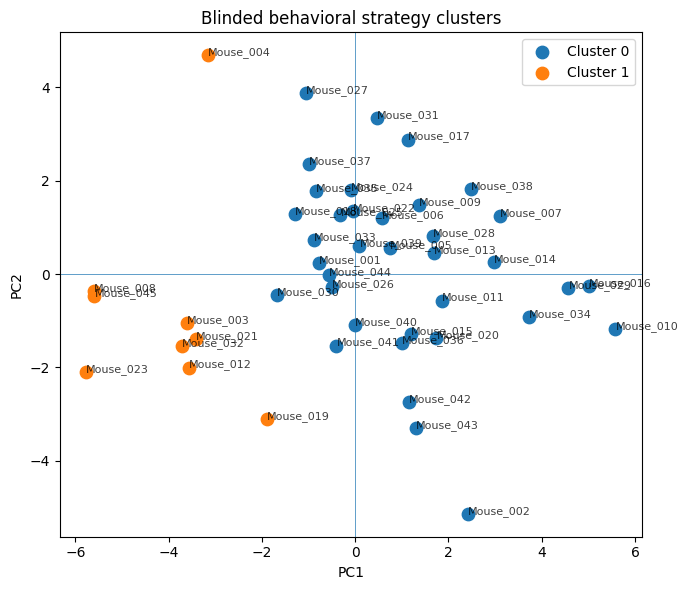

In [65]:
exclude_cols = ["mouse_id", "blind_mouse_id"]
feature_cols = [
    c
    for c in strategy_features_blind.columns
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(strategy_features_blind[c])
]
X_raw = strategy_features_blind[feature_cols].copy()
preprocess = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
X = preprocess.fit_transform(X_raw)
kmeans = KMeans(n_clusters=2, random_state=2026, n_init=100)
strategy_features_blind["cluster_kmeans_2"] = kmeans.fit_predict(X)
agg = AgglomerativeClustering(n_clusters=2)
strategy_features_blind["cluster_agglomerative_2"] = agg.fit_predict(X)
gmm = GaussianMixture(n_components=2, random_state=2026, n_init=50)
strategy_features_blind["cluster_gmm_2"] = gmm.fit_predict(X)
strategy_features_blind["cluster_gmm_probability"] = gmm.predict_proba(X).max(axis=1)
pca = PCA(n_components=2, random_state=2026)
X_pca = pca.fit_transform(X)
strategy_features_blind["PC1"] = X_pca[:, 0]
strategy_features_blind["PC2"] = X_pca[:, 1]
cluster_path = BLIND_DIR / "blinded_mouse_strategy_clusters.csv"
strategy_features_blind.to_csv(cluster_path, index=False)
plt.figure(figsize=(7, 6))
for cl in sorted(strategy_features_blind["cluster_kmeans_2"].unique()):
    sub = strategy_features_blind[strategy_features_blind["cluster_kmeans_2"] == cl]
    plt.scatter(sub["PC1"], sub["PC2"], s=80, label=f"Cluster {cl}")
for _, row in strategy_features_blind.iterrows():
    plt.text(row["PC1"], row["PC2"], row["blind_mouse_id"], fontsize=8, alpha=0.75)
plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Blinded behavioral strategy clusters")
plt.legend()
plt.tight_layout()
fig_path = BLIND_DIR / "blinded_strategy_clusters_pca.png"
plt.savefig(fig_path, dpi=300)
plt.show()

In [66]:
state_occ_cols = [
    c for c in strategy_features_blind.columns if c.startswith("state_") and c.endswith("_occupancy")
]
if len(state_occ_cols) == 0:
    raise ValueError("No state occupancy columns found.")
for c in state_occ_cols:
    strategy_features_blind[c] = strategy_features_blind[c].fillna(0)
DOMINANT_THRESHOLD = 0.6
MARGIN_THRESHOLD = 0.15


def assign_dominant_state_group(row):
    occ = row[state_occ_cols].astype(float)
    top_col = occ.idxmax()
    top_occ = occ.max()
    sorted_occ = occ.sort_values(ascending=False)
    second_occ = sorted_occ.iloc[1] if len(sorted_occ) > 1 else 0
    top_state = top_col.replace("_occupancy", "").replace("state_", "")
    margin = top_occ - second_occ
    if top_occ >= DOMINANT_THRESHOLD and margin >= MARGIN_THRESHOLD:
        return f"State_{top_state}_dominant"
    else:
        return "Mixed"


strategy_features_blind["dominant_strategy_group"] = strategy_features_blind.apply(
    assign_dominant_state_group, axis=1
)
strategy_features_blind["dominant_state"] = (
    strategy_features_blind[state_occ_cols]
    .idxmax(axis=1)
    .str.replace("_occupancy", "", regex=False)
    .str.replace("state_", "", regex=False)
    .astype(int)
)
strategy_features_blind["dominant_state_occupancy"] = strategy_features_blind[state_occ_cols].max(axis=1)
strategy_features_blind["second_highest_state_occupancy"] = (
    np.sort(strategy_features_blind[state_occ_cols].values, axis=1)[:, -2] if len(state_occ_cols) > 1 else 0
)
strategy_features_blind["dominant_minus_second_occupancy"] = (
    strategy_features_blind["dominant_state_occupancy"]
    - strategy_features_blind["second_highest_state_occupancy"]
)
group_cols = [
    "blind_mouse_id",
    "mouse_id",
    "dominant_strategy_group",
    "dominant_state",
    "dominant_state_occupancy",
    "second_highest_state_occupancy",
    "dominant_minus_second_occupancy",
    "overall_accuracy",
] + state_occ_cols
group_cols = [c for c in group_cols if c in strategy_features_blind.columns]
dominant_group_path = BLIND_DIR / f"blinded_dominant_state_strategy_groups_K{K_TO_INTERPRET}.csv"
strategy_features_blind[group_cols].to_csv(dominant_group_path, index=False)
dominant_summary = strategy_features_blind["dominant_strategy_group"].value_counts().reset_index()
dominant_summary.columns = ["dominant_strategy_group", "n_mice"]
dominant_summary_path = BLIND_DIR / f"dominant_state_group_counts_K{K_TO_INTERPRET}.csv"
dominant_summary.to_csv(dominant_summary_path, index=False)

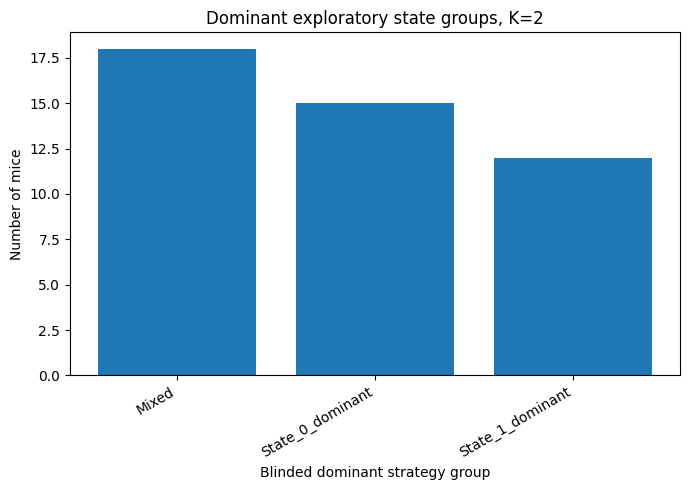

In [67]:
plt.figure(figsize=(7, 5))
plt.bar(dominant_summary["dominant_strategy_group"], dominant_summary["n_mice"])
plt.xlabel("Blinded dominant strategy group")
plt.ylabel("Number of mice")
plt.title(f"Dominant exploratory state groups, K={K_TO_INTERPRET}")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
fig_path = BLIND_DIR / f"dominant_state_group_counts_K{K_TO_INTERPRET}.png"
plt.savefig(fig_path, dpi=300)
plt.show()

In [68]:
freeze_cols = [
    "blind_mouse_id",
    "dominant_strategy_group",
    "dominant_state",
    "dominant_state_occupancy",
    "second_highest_state_occupancy",
    "dominant_minus_second_occupancy",
    "state_0_occupancy",
    "state_1_occupancy",
    "overall_accuracy",
]
freeze_cols = [c for c in freeze_cols if c in strategy_features_blind.columns]
frozen_dominant_path = BLIND_DIR / f"FROZEN_dominant_state_groups_BEFORE_UNBLINDING_K{K_TO_INTERPRET}.csv"
strategy_features_blind[freeze_cols].to_csv(frozen_dominant_path, index=False)

In [69]:
UNBLINDING_KEY_PATH = PROJECT_DIR / "mouse_genotype_unblinding_key.csv"
if not UNBLINDING_KEY_PATH.exists():
    template = pd.DataFrame(
        {
            "mouse_id": sorted(strategy_features_blind["mouse_id"].astype(str).unique()),
            "genotype": "FILL_Control_OR_Setd1a_mutant",
        }
    )
    template.to_csv(UNBLINDING_KEY_PATH, index=False)